In [306]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [307]:
import requests
import json

In [308]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

I'm starting with downloading data about prices of gas, energy, and use of those goods in industrial sector

In [309]:
url = "https://api.eia.gov/v2/seds/data/?frequency=annual&data[0]=value&facets[seriesId][]=ESICD&facets[seriesId][]=NGICD&facets[seriesId][]=PEICD&facets[seriesId][]=TEICB&facets[seriesId][]=TEICV&start=2000&end=2024&sort[0][column]=period&sort[0][direction]=desc&offset=1240&length=5000&api_key=z3VpFxvqtUTZLxd6waPkazGOR9dhE4TrTMs5fWbE"

response = requests.get(url)
data = response.json()
records = data["response"]["data"]

with open('pricesData.json', 'w', encoding='utf-8') as f:
    json.dump(records, f, indent=4) 

In [310]:
df = pd.read_json('pricesData.json')
df.head()


,period,seriesId,seriesDescription,stateId,stateDescription,value,unit
0,2019,NGICD,Natural gas price in the industrial sector (in...,US,United States,4.60,Dollars per million Btu
1,2019,NGICD,Natural gas price in the industrial sector (in...,UT,Utah,4.77,Dollars per million Btu
2,2019,NGICD,Natural gas price in the industrial sector (in...,VA,Virginia,4.41,Dollars per million Btu
3,2019,NGICD,Natural gas price in the industrial sector (in...,VT,Vermont,3.99,Dollars per million Btu
4,2019,NGICD,Natural gas price in the industrial sector (in...,WA,Washington,6.32,Dollars per million Btu


In [311]:
df['stateDescription'].unique()

array(['United States', 'Utah', 'Virginia', 'Vermont', 'Washington',
       'Wisconsin', 'West Virginia', 'Wyoming', 'Alaska', 'Alabama',
       'Arkansas', 'Arizona', 'California', 'Colorado', 'Connecticut',
       'District of Columbia', 'Delaware', 'Florida', 'Georgia', 'Hawaii',
       'Iowa', 'Idaho', 'Illinois', 'Indiana', 'Kansas', 'Kentucky',
       'Louisiana', 'Massachusetts', 'Maryland', 'Maine', 'Michigan',
       'Minnesota', 'Missouri', 'Mississippi', 'Montana',
       'North Carolina', 'North Dakota', 'Nebraska', 'New Hampshire',
       'New Jersey', 'New Mexico', 'Nevada', 'New York', 'Ohio',
       'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
       'South Carolina', 'South Dakota', 'Tennessee', 'Texas'],
      dtype=object)

In list of states, there is one extra position - United States. I have to prevent my data from extra positions that could destroy aggregation, that's why I have to remove that position before further steps

In [312]:
df = df[df['stateId'] != 'US']
df['stateDescription'].unique()

array(['Utah', 'Virginia', 'Vermont', 'Washington', 'Wisconsin',
       'West Virginia', 'Wyoming', 'Alaska', 'Alabama', 'Arkansas',
       'Arizona', 'California', 'Colorado', 'Connecticut',
       'District of Columbia', 'Delaware', 'Florida', 'Georgia', 'Hawaii',
       'Iowa', 'Idaho', 'Illinois', 'Indiana', 'Kansas', 'Kentucky',
       'Louisiana', 'Massachusetts', 'Maryland', 'Maine', 'Michigan',
       'Minnesota', 'Missouri', 'Mississippi', 'Montana',
       'North Carolina', 'North Dakota', 'Nebraska', 'New Hampshire',
       'New Jersey', 'New Mexico', 'Nevada', 'New York', 'Ohio',
       'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
       'South Carolina', 'South Dakota', 'Tennessee', 'Texas'],
      dtype=object)

Data was cleaned, there's no more 'United States' record

In [313]:
df.groupby("period")["stateId"].count()

period
2000    153
2001    255
2002    255
2003    255
2004    255
2005    255
2006    255
2007    255
2008    255
2009    255
2010    255
2011    255
2012    255
2013    255
2014    255
2015    255
2016    255
2017    255
2018    255
2019    160
Name: stateId, dtype: int64

For years 2000 and 2019 there is less records than for years 2001-2018, that's why I have to clean data in order to compare it. I will leave only data from 2001 - 2018 

In [314]:
df = df[(df['period'] >= 2001) & (df['period'] <= 2018)]

In [315]:
df.groupby("period")["stateId"].count()

period
2001    255
2002    255
2003    255
2004    255
2005    255
2006    255
2007    255
2008    255
2009    255
2010    255
2011    255
2012    255
2013    255
2014    255
2015    255
2016    255
2017    255
2018    255
Name: stateId, dtype: int64

In [316]:
df_states = df[['stateId', 'stateDescription']].drop_duplicates()
df_series = df[['seriesId', 'seriesDescription']].drop_duplicates()

In [317]:
df.drop(columns=['seriesDescription', 'stateDescription'], inplace=True)


Btu isn't a unit that is clear for Europe countires. To make data more transparente, I will change Dollars per million Btu to Dollars per MWh

In [318]:
df_teicb=df[df["seriesId"] == "TEICB"]
df_peicd=df[df["seriesId"] == "PEICD"]
df_teicv=df[df["seriesId"] == "TEICV"]
df_esicd=df[df["seriesId"] == "ESICD"]
df_ngicd=df[df["seriesId"] == "NGICD"]

In [319]:
df_teicb.head()

,period,seriesId,stateId,value,unit
320,2018,TEICB,AK,331478.0,Billion Btu
321,2018,TEICB,AL,829542.0,Billion Btu
322,2018,TEICB,AR,406022.0,Billion Btu
323,2018,TEICB,AZ,219663.0,Billion Btu
324,2018,TEICB,CA,1739402.0,Billion Btu


In [320]:
df_teicb = df_teicb.copy()

In [321]:
df_teicb['value'] = df_teicb['value'] * 293
df_teicb[ 'unit'] = 'MWh'

In [322]:
df_teicb.rename(columns={'value': 'MWh'}, inplace=True)
df_teicb.drop(columns=['unit'], inplace=True)

In [323]:
df_teicb.head()

,period,seriesId,stateId,MWh
320,2018,TEICB,AK,97123054.0
321,2018,TEICB,AL,243055806.0
322,2018,TEICB,AR,118964446.0
323,2018,TEICB,AZ,64361259.0
324,2018,TEICB,CA,509644786.0


In [324]:
df_peicd.head()

,period,seriesId,stateId,value,unit
268,2018,PEICD,AK,18.99,Dollars per million Btu
269,2018,PEICD,AL,5.28,Dollars per million Btu
270,2018,PEICD,AR,7.86,Dollars per million Btu
271,2018,PEICD,AZ,14.55,Dollars per million Btu
272,2018,PEICD,CA,10.27,Dollars per million Btu


In [325]:
df_peicd  =df_peicd.copy()

In [326]:
df_peicd['value'] = df_peicd['value'] * 3.412

In [327]:
df_peicd.rename(columns={'value': 'Dollars per MWh'}, inplace=True)
df_peicd.drop(columns=['unit'], inplace=True)

In [328]:
df_peicd.head()

,period,seriesId,stateId,Dollars per MWh
268,2018,PEICD,AK,64.79388
269,2018,PEICD,AL,18.01536
270,2018,PEICD,AR,26.81832
271,2018,PEICD,AZ,49.64460
272,2018,PEICD,CA,35.04124


In [329]:
df_teicv.head()

,period,seriesId,stateId,value,unit
372,2018,TEICV,AK,616.2,Million dollars
373,2018,TEICV,AL,4447.3,Million dollars
374,2018,TEICV,AR,2601.9,Million dollars
375,2018,TEICV,AZ,2168.4,Million dollars
376,2018,TEICV,CA,15417.9,Million dollars


In [330]:
df_teicv = df_teicv.copy()

In [331]:
df_teicv.rename(columns={'value': 'Million dollars'}, inplace=True)
df_teicv.drop(columns=['unit'], inplace=True)

In [332]:
df_teicv.head()

,period,seriesId,stateId,Million dollars
372,2018,TEICV,AK,616.2
373,2018,TEICV,AL,4447.3
374,2018,TEICV,AR,2601.9
375,2018,TEICV,AZ,2168.4
376,2018,TEICV,CA,15417.9


In [333]:
df_esicd.head()

,period,seriesId,stateId,value,unit
164,2018,ESICD,AK,50.13,Dollars per million Btu
165,2018,ESICD,AL,17.62,Dollars per million Btu
166,2018,ESICD,AR,16.53,Dollars per million Btu
167,2018,ESICD,AZ,19.19,Dollars per million Btu
168,2018,ESICD,CA,38.69,Dollars per million Btu


In [334]:
df_esicd = df_esicd.copy()

In [335]:
df_esicd['value'] = df_esicd['value'] * 3.412

In [336]:
df_esicd.rename(columns={'value': 'Dollars per MWh'}, inplace=True)
df_esicd.drop(columns=['unit'], inplace=True)

In [337]:
df_esicd.head()

,period,seriesId,stateId,Dollars per MWh
164,2018,ESICD,AK,171.04356
165,2018,ESICD,AL,60.11944
166,2018,ESICD,AR,56.40036
167,2018,ESICD,AZ,65.47628
168,2018,ESICD,CA,132.01028


In [338]:
df_ngicd.head()

,period,seriesId,stateId,value,unit
216,2018,NGICD,AK,5.97,Dollars per million Btu
217,2018,NGICD,AL,4.11,Dollars per million Btu
218,2018,NGICD,AR,6.69,Dollars per million Btu
219,2018,NGICD,AZ,5.75,Dollars per million Btu
220,2018,NGICD,CA,6.89,Dollars per million Btu


In [339]:
df_ngicd = df_ngicd.copy()

In [340]:
df_ngicd['value'] = df_ngicd['value'] * 3.412

In [341]:
df_ngicd.rename(columns={'value': 'Dollars per MWh'}, inplace=True)
df_ngicd.drop(columns=['unit'], inplace=True)

In [342]:
df_ngicd.head()

,period,seriesId,stateId,Dollars per MWh
216,2018,NGICD,AK,20.36964
217,2018,NGICD,AL,14.02332
218,2018,NGICD,AR,22.82628
219,2018,NGICD,AZ,19.61900
220,2018,NGICD,CA,23.50868


Now data in tables with prices and usage of energy is normalized

In [343]:
df_prices = df_esicd.merge(df_ngicd, on=['period', 'stateId'], how='right')
df_prices.rename(columns={'Dollars per MWh_x': 'Electricity price', 'Dollars per MWh_y': 'Natural gas price'}, inplace=True)
df_prices.drop(columns=['seriesId_x', 'seriesId_y'], inplace=True)
df_prices.head()

,period,stateId,Electricity price,Natural gas price
0,2018,AK,171.04356,20.36964
1,2018,AL,60.11944,14.02332
2,2018,AR,56.40036,22.82628
3,2018,AZ,65.47628,19.61900
4,2018,CA,132.01028,23.50868


In [344]:
df_prices.isnull().sum()

period               0
stateId              0
Electricity price    0
Natural gas price    0
dtype: int64

In [345]:
df_prices.describe()

,period,Electricity price,Natural gas price
count,918.000000,918.000000,918.000000
mean,2009.500000,71.406358,24.431816
std,5.190956,33.314343,11.074556
min,2001.000000,30.400920,0.000000
25%,2005.000000,51.828280,17.921530
50%,2009.500000,62.371360,22.775100
75%,2014.000000,77.981260,30.162080
max,2018.000000,308.205960,100.756360


In df_prices there is minimum price for natural gas equals 0. I have to check that data

In [346]:
df_prices[df_prices['Natural gas price'] == 0]

,period,stateId,Electricity price,Natural gas price
7,2018,DC,82.94572,0.0
58,2017,DC,82.29744,0.0
109,2016,DC,88.02960,0.0
160,2015,DC,87.85900,0.0
211,2014,DC,84.10580,0.0
262,2013,DC,55.37676,0.0
306,2012,AK,168.21160,0.0
313,2012,DC,54.59200,0.0
357,2011,AK,157.08848,0.0
364,2011,DC,68.88828,0.0


I will replace those data with medium value for this state, despite the fact that I'm expecting the biggest changes in production during economical crisis of the year 2008

In [347]:
alaska_mean = df_prices[(df_prices["stateId"] == "AK") & (df_prices["Natural gas price"] > 0)]["Natural gas price"].mean()
alaska_mean = alaska_mean.round(2)

In [348]:
print(alaska_mean)

14.72


In [349]:
df_prices.loc[(df_prices["stateId"] == "AK") & (df_prices["Natural gas price"] == 0),"Natural gas price"] = alaska_mean

In [350]:
df_prices[(df_prices["stateId"] == 'AK')]

,period,stateId,Electricity price,Natural gas price
0,2018,AK,171.04356,20.36964
51,2017,AK,163.40068,16.00228
102,2016,AK,152.17520,17.23060
153,2015,AK,145.24884,23.37220
204,2014,AK,156.64492,27.15952
255,2013,AK,158.31680,27.80780
306,2012,AK,168.21160,14.72000
357,2011,AK,157.08848,14.72000
408,2010,AK,141.46152,14.72000
459,2009,AK,131.46436,14.72000


There is missing value for gas price in DC - I will analyze that state only for electric energy price
In Alaska there is missing data for some years

In [351]:
df_prices['Natural gas price'] = df_prices['Natural gas price'].replace(0, np.nan)

In [352]:
folder = r"\331"
files = [f for f in os.listdir(folder) if f.endswith("PRIMETMANNGSP.csv")]
dfs = {}
for file in files:
    state = file[:2]
    dfs[state] = pd.read_csv(os.path.join(folder, file))
    globals()[state.lower() + '331'] = dfs[state]

In [353]:
all_dfs = []
for state, df in dfs.items():
    df_copy = df.copy()
    df_copy['stateId'] = state
    df_copy['period'] = pd.to_datetime(df_copy['observation_date']).dt.year
    df_copy['aluminum_production'] = df_copy[state + 'PRIMETMANNGSP']
    df_copy['unit'] = 'MillionOfDollars'
    df_copy = df_copy[['period', 'stateId', 'aluminum_production', 'unit']]
    all_dfs.append(df_copy)
usa331 = pd.concat(all_dfs, ignore_index=True)
usa331

,period,stateId,aluminum_production,unit
0,2002,AK,0.9,MillionOfDollars
1,2003,AK,1.3,MillionOfDollars
2,2004,AK,2.4,MillionOfDollars
3,2005,AK,1.7,MillionOfDollars
4,2006,AK,1.3,MillionOfDollars
...,...,...,...,...
875,2014,WY,10.1,MillionOfDollars
876,2015,WY,9.3,MillionOfDollars
877,2016,WY,8.6,MillionOfDollars
878,2017,WY,8.7,MillionOfDollars


Hipothesis: Price of electric energy had impact on aluminum production, it was main factor in decisions about closing smelters

In [354]:
pricesToProduction = pd.merge(df_prices, usa331, on=['period','stateId'], how='inner')
pricesToProduction.rename(columns={'aluminum_production': 'aluminum_production[MlnDollars]'}, inplace=True)
pricesToProduction.drop(columns=['unit'], inplace=True)
pricesToProduction 

,period,stateId,Electricity price,Natural gas price,aluminum_production[MlnDollars]
0,2018,AK,171.04356,20.36964,1.5
1,2018,AL,60.11944,14.02332,4502.6
2,2018,AR,56.40036,22.82628,2241.5
3,2018,AZ,65.47628,19.61900,903.2
4,2018,CA,132.01028,23.50868,2388.5
...,...,...,...,...,...
875,2001,VT,78.88544,16.92352,33.6
876,2001,WA,47.52916,16.54820,748.6
877,2001,WI,43.63948,25.28292,1260.9
878,2001,WV,37.39552,15.21752,579.9


In [355]:
pricesToProduction[['Electricity price', 'Natural gas price', 'aluminum_production[MlnDollars]']].corr()

,Electricity price,Natural gas price,aluminum_production[MlnDollars]
Electricity price,1.000000,0.599143,-0.174478
Natural gas price,0.599143,1.000000,-0.044378
aluminum_production[MlnDollars],-0.174478,-0.044378,1.000000


Price of electric energy has impact on aluminium production, however it isn't meaningfull impact.
Price of gas has no impact for aluminium production - natural gas isn't used in aluminium smelters.

In [356]:
pricesToProduction = pricesToProduction.sort_values(['stateId', 'period'])

In [357]:
pricesToProduction['energyLag1'] = (pricesToProduction.groupby('stateId')['Electricity price'].shift(1))

In [358]:
pricesToProduction[['energyLag1', 'aluminum_production[MlnDollars]']].corr()

,energyLag1,aluminum_production[MlnDollars]
energyLag1,1.000000,-0.180541
aluminum_production[MlnDollars],-0.180541,1.000000


Change of the electrical energy price has negative impact for aluminium production. When pricve of energy raises 1%, the level of production falls for 3%. However, the price of electrical energy stands for 18,9% changes in aluminium production. It means that I have to check other sources that have impact for production, because this isn't main factor. 

The impacrt of prices from previous years is smaller than impact of the prices of energy in current years

In [359]:
%matplotlib inline

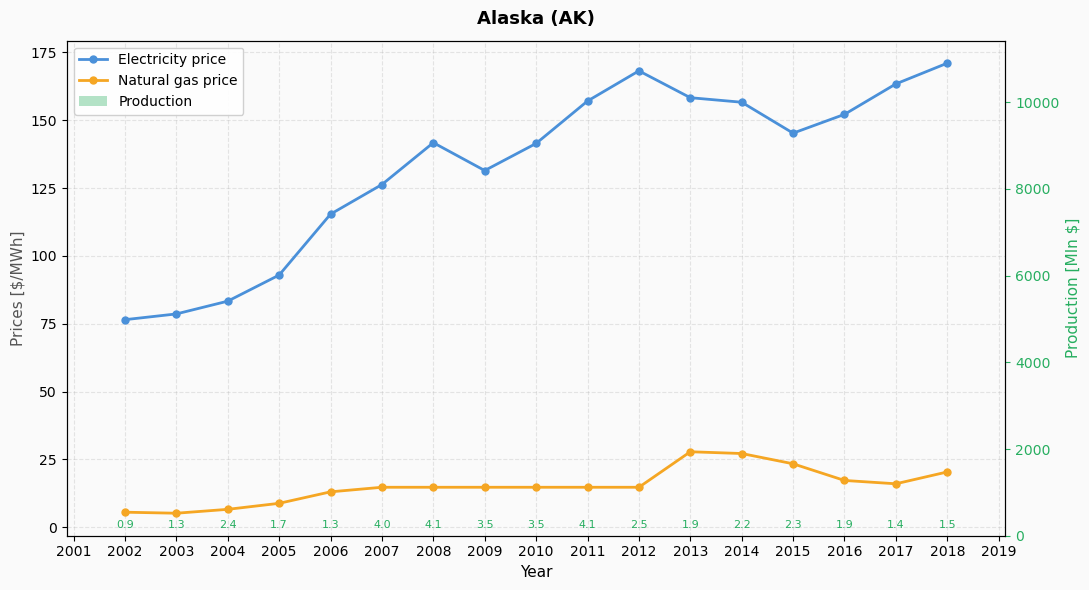

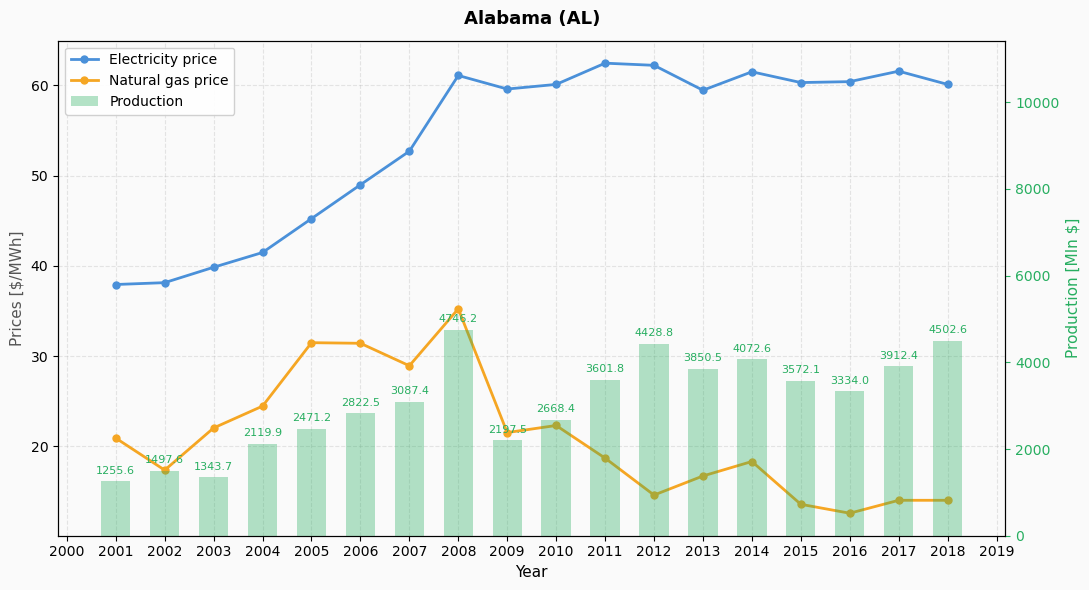

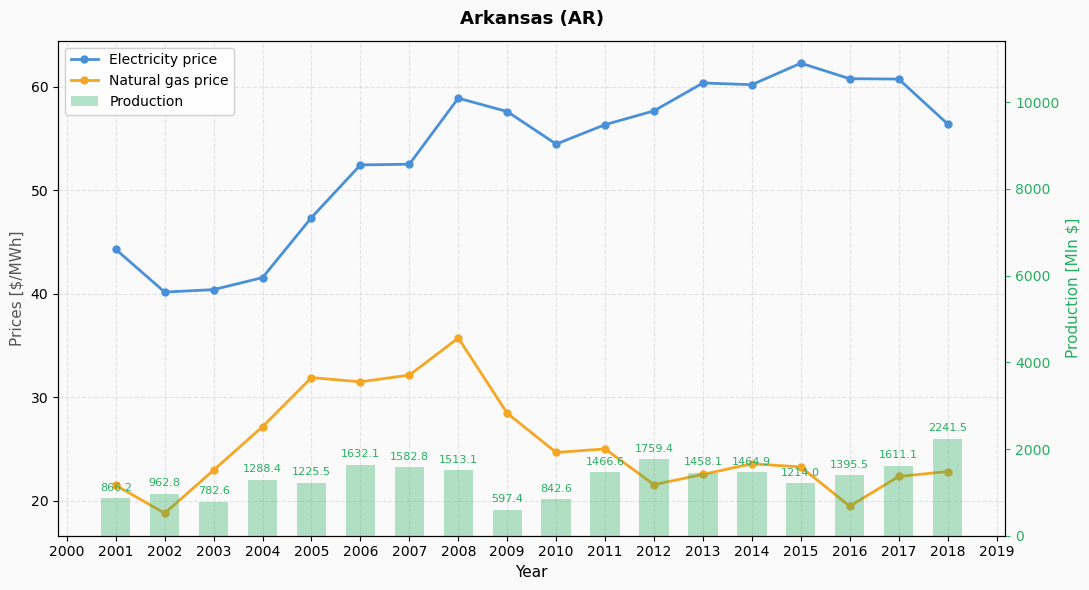

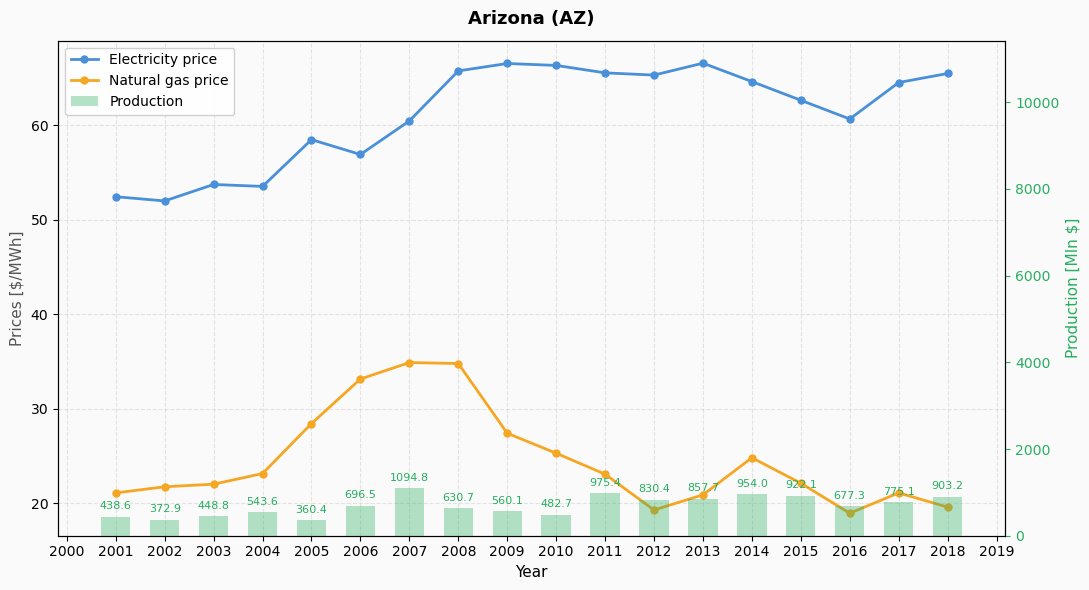

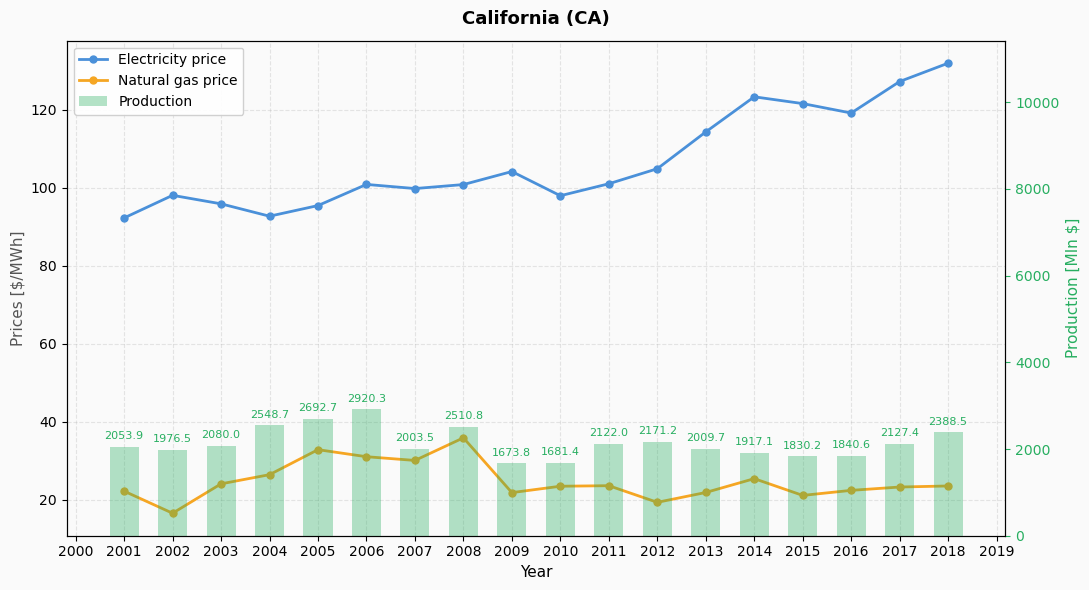

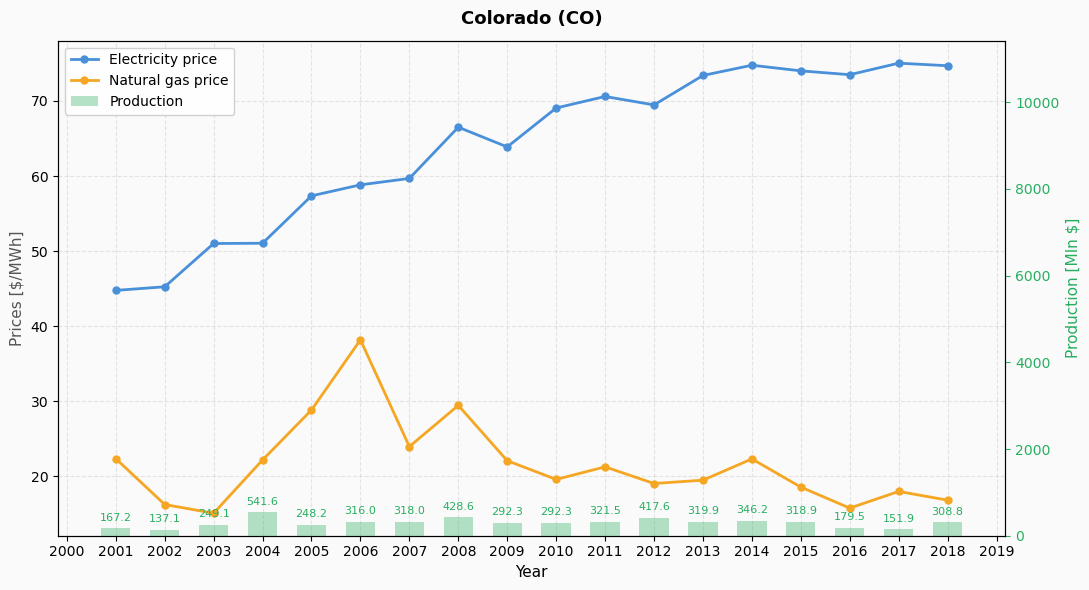

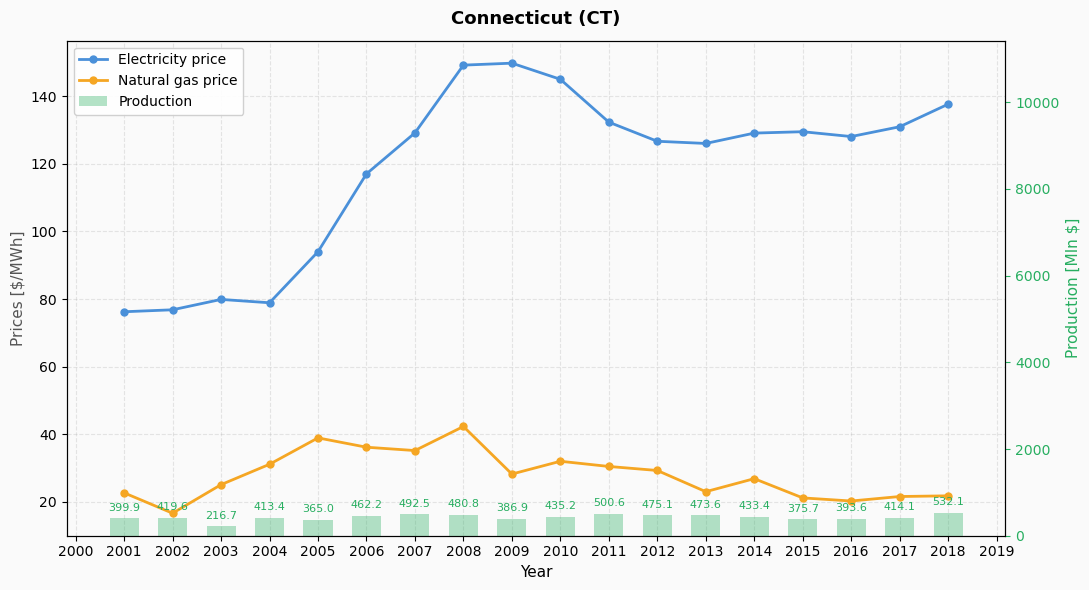

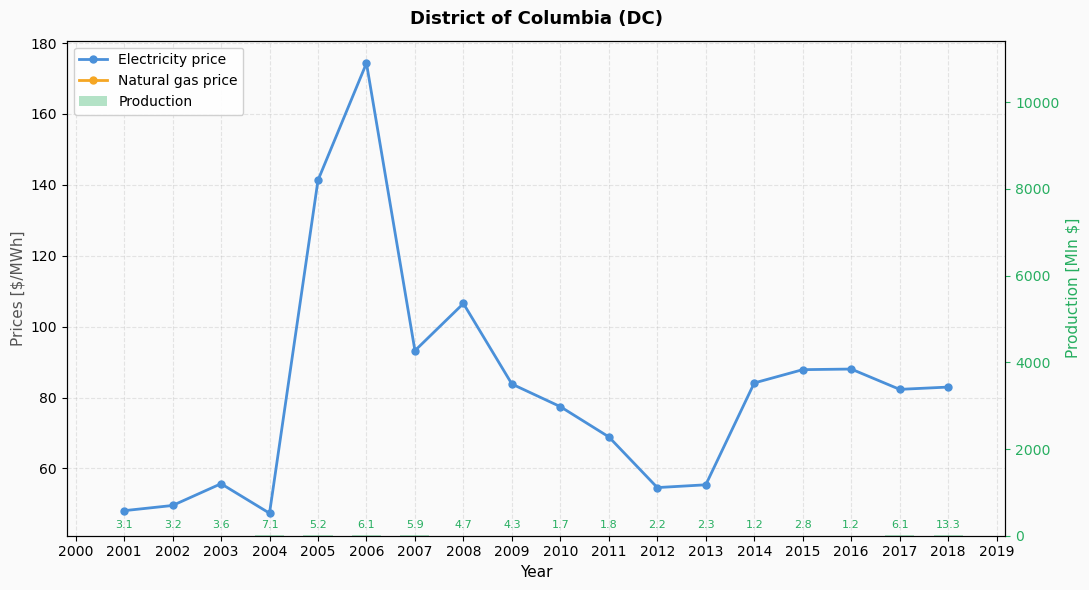

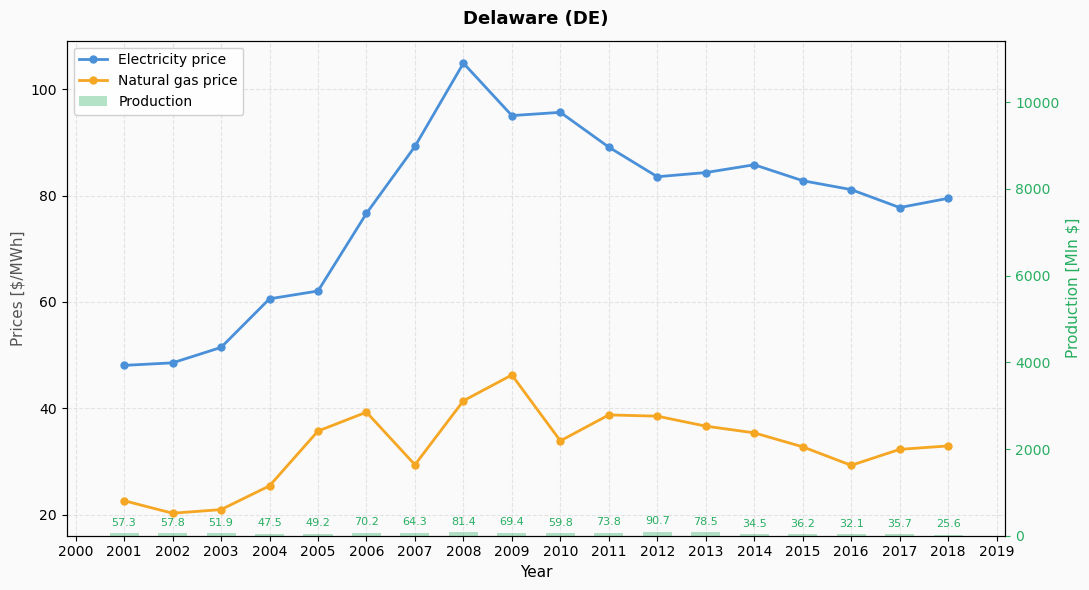

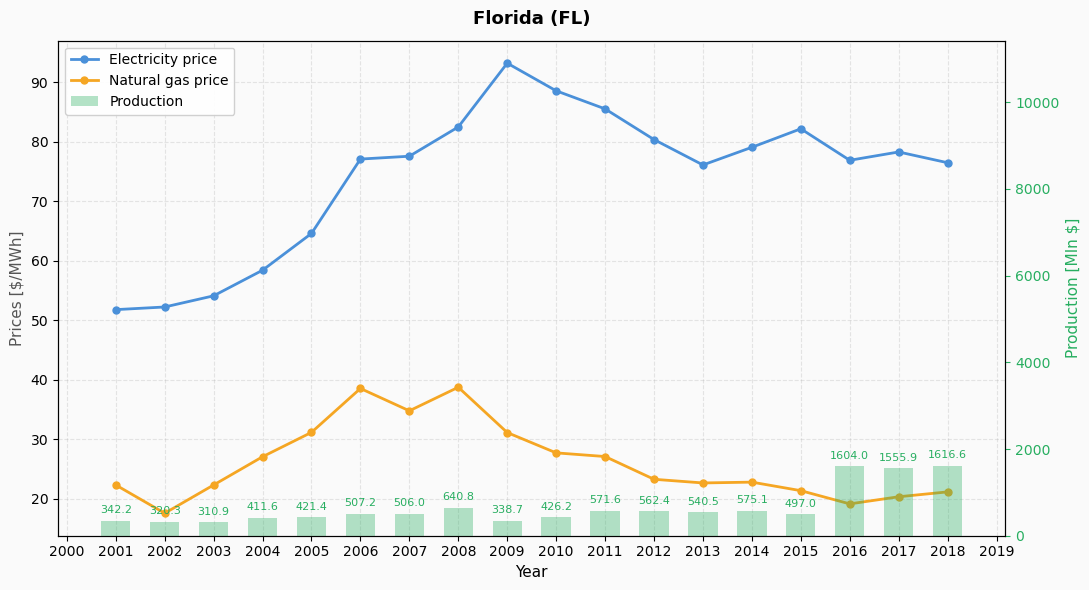

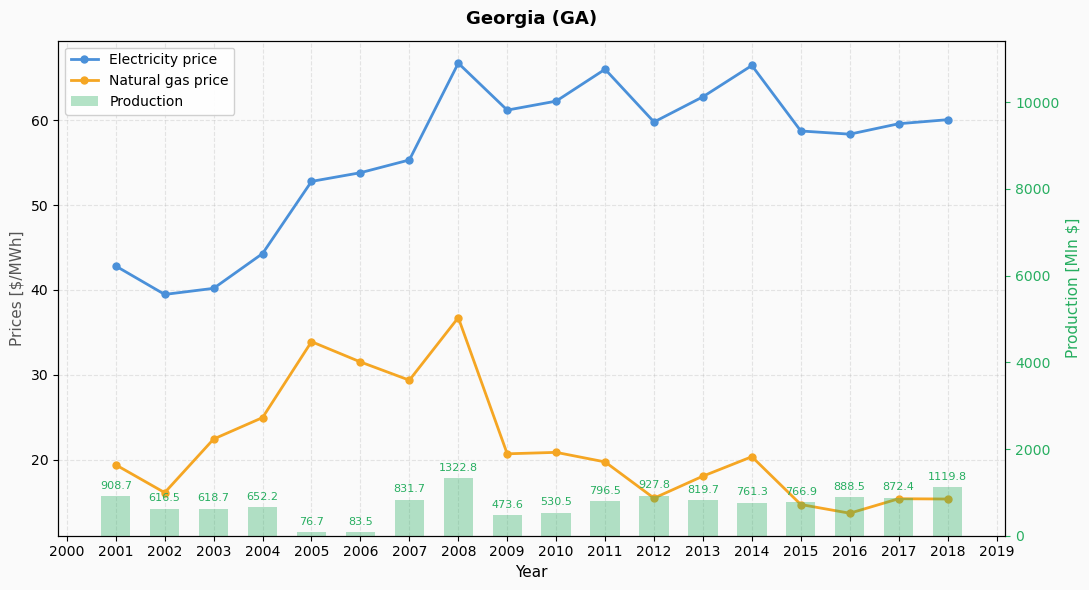

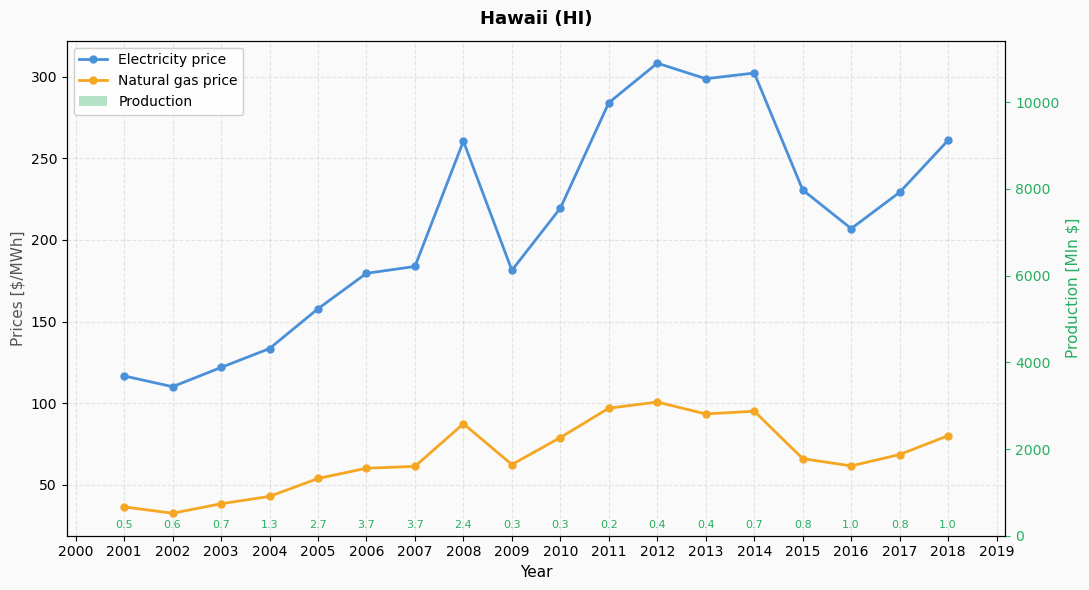

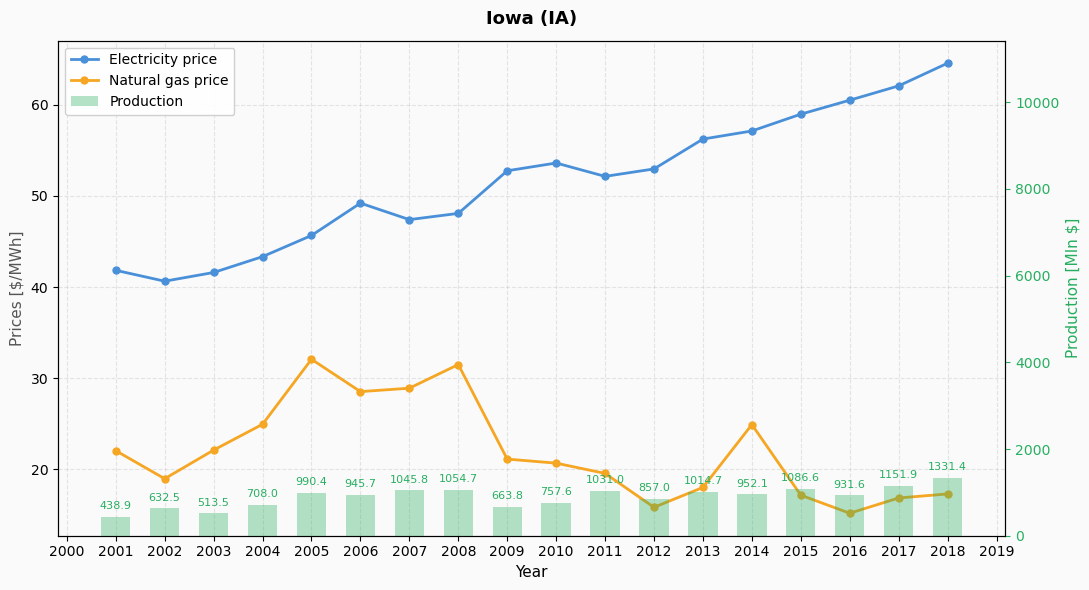

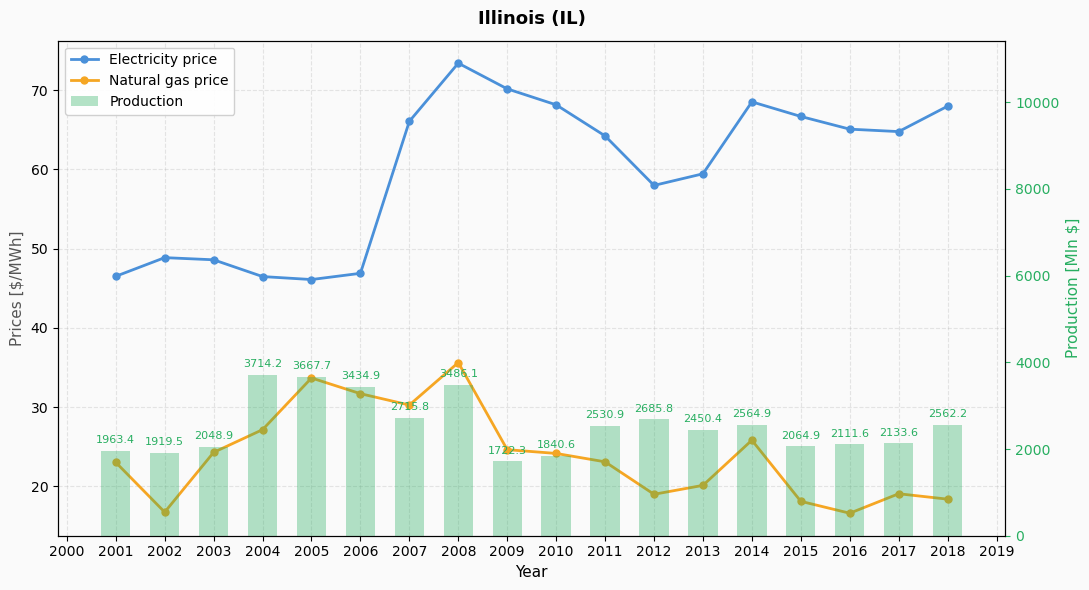

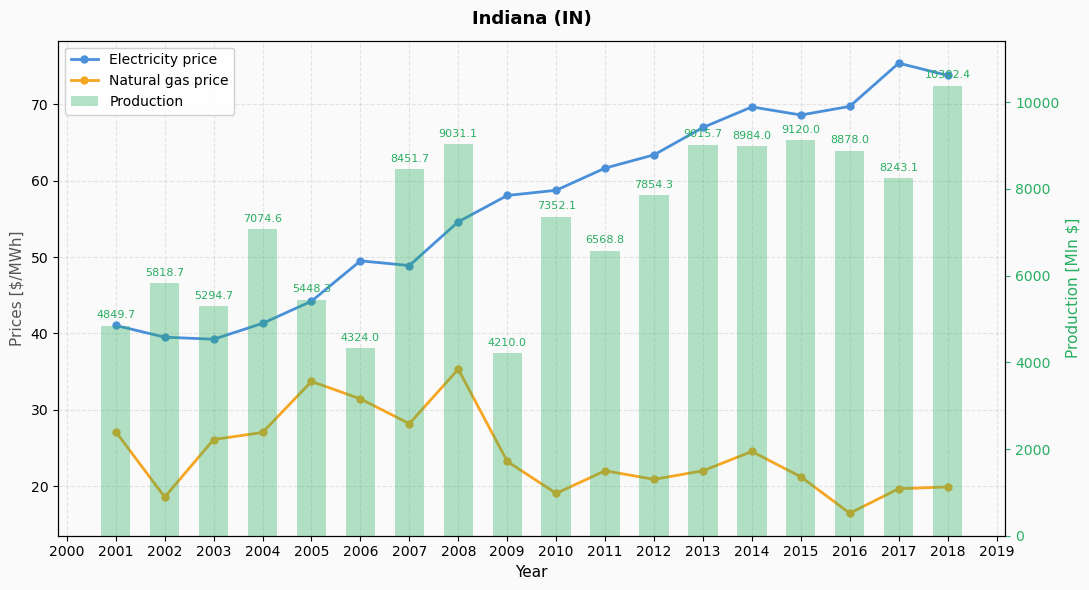

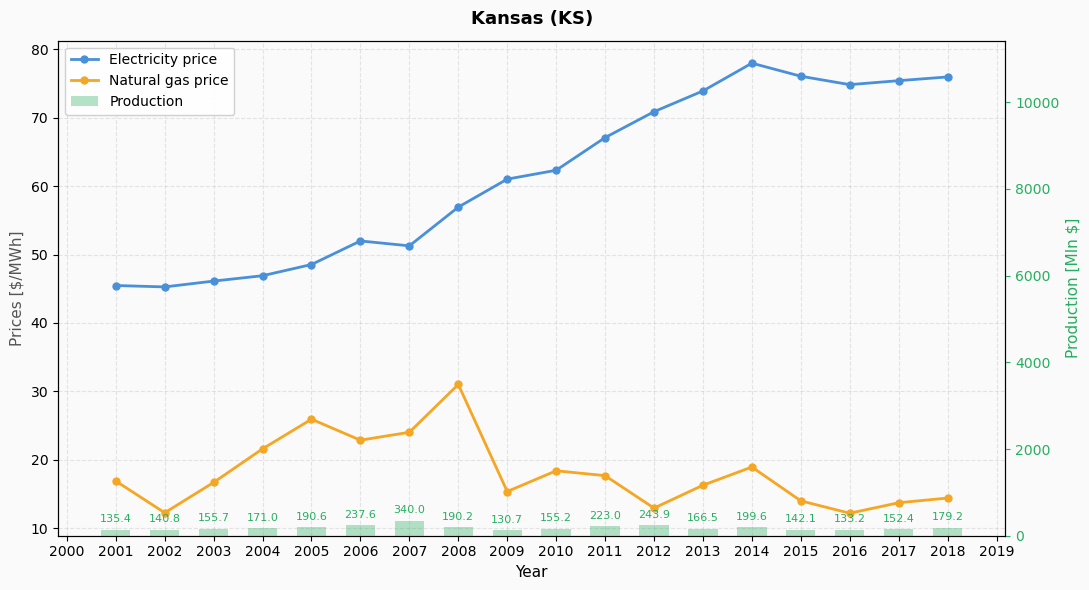

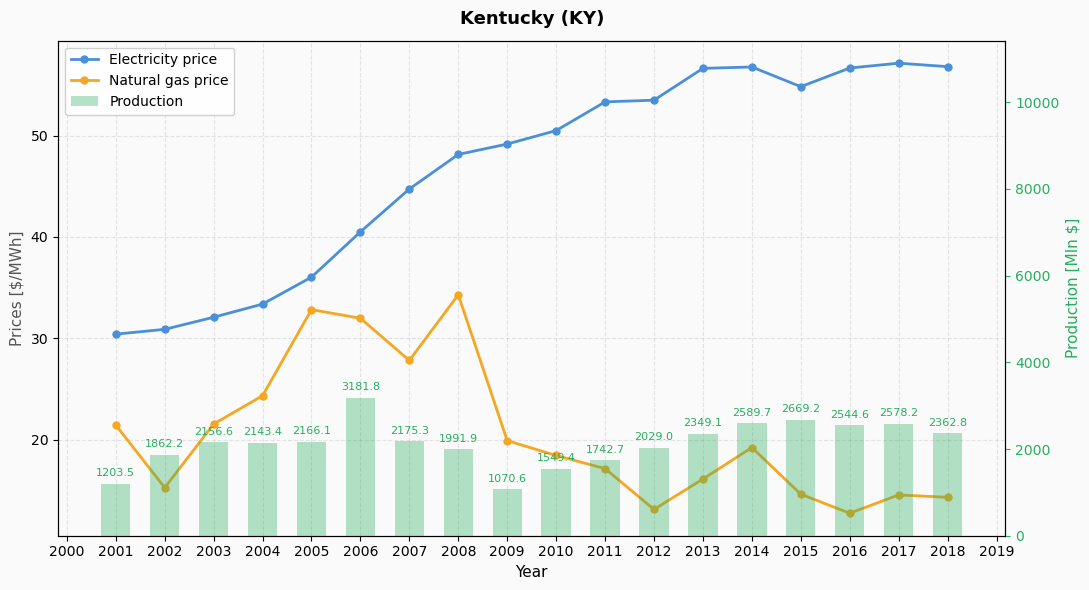

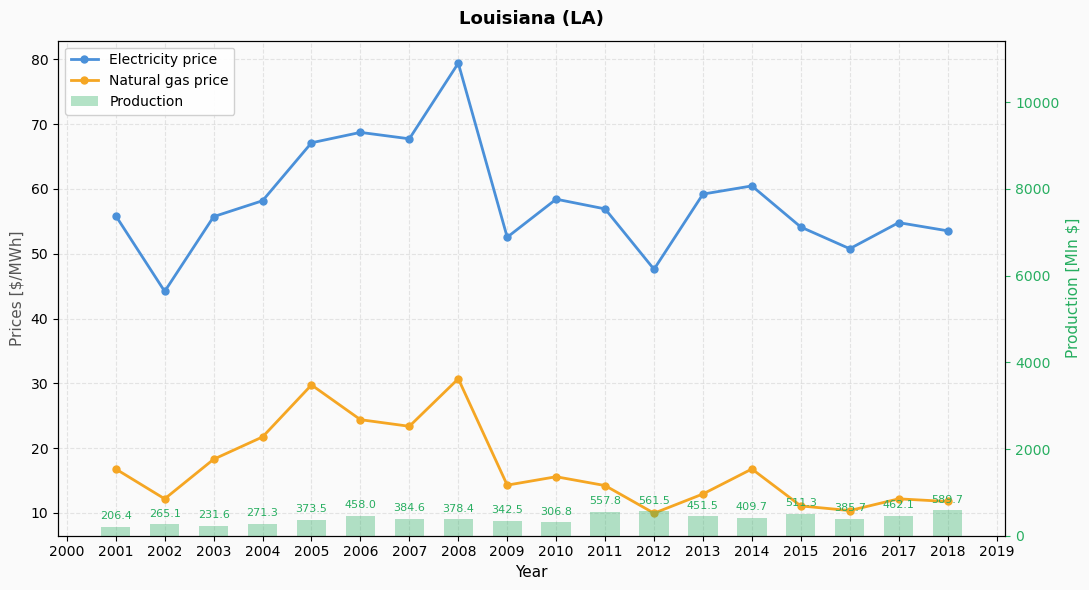

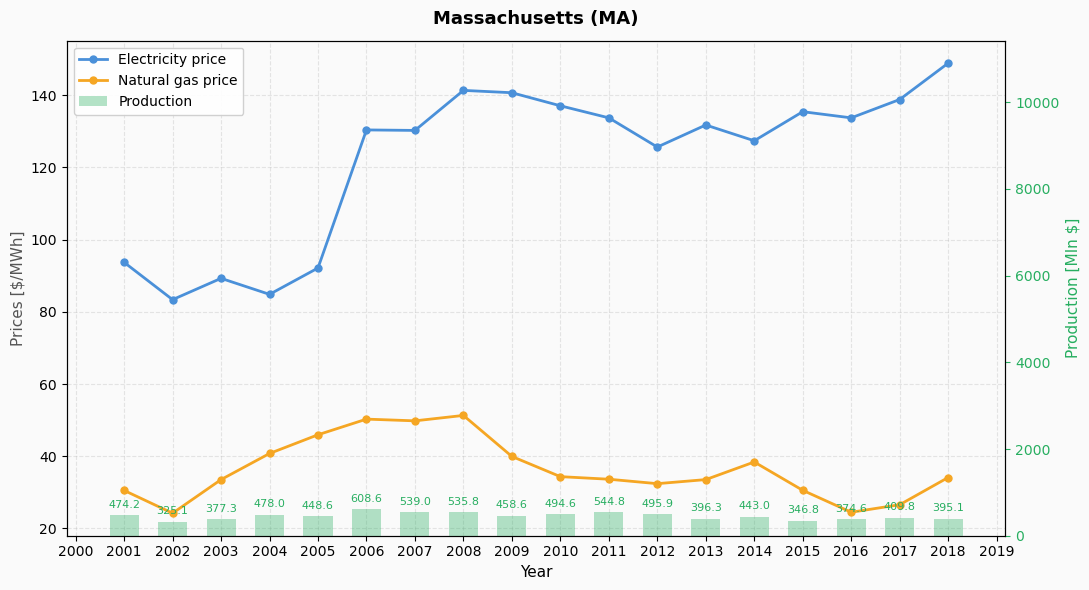

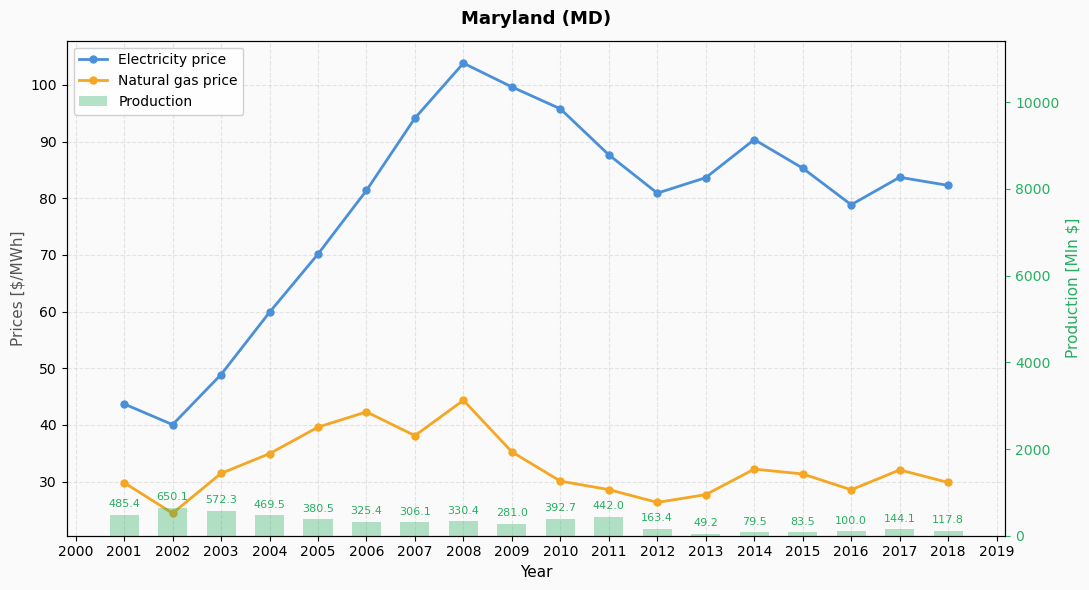

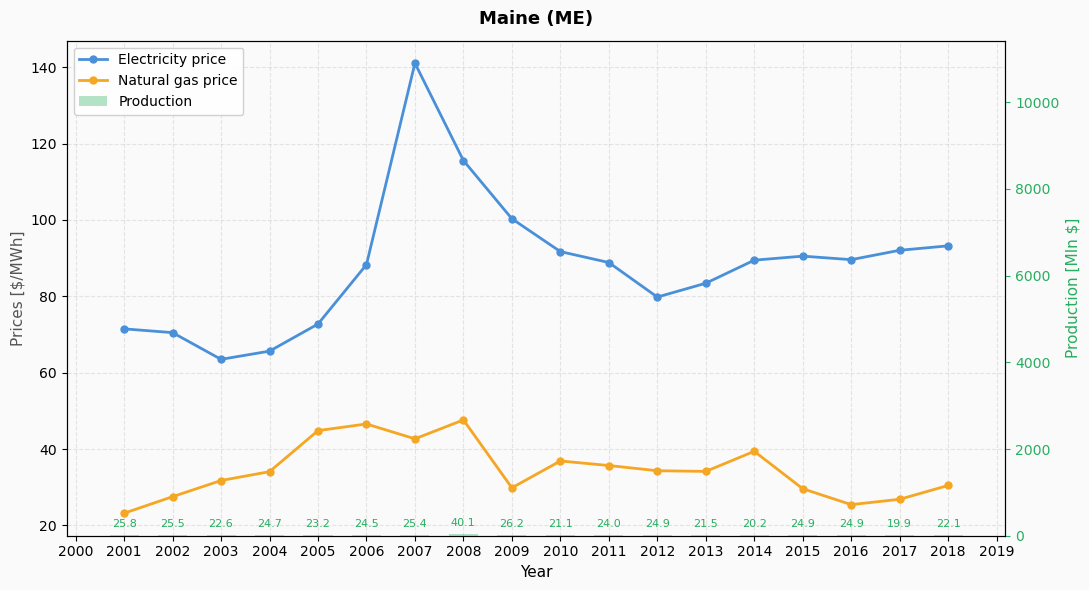

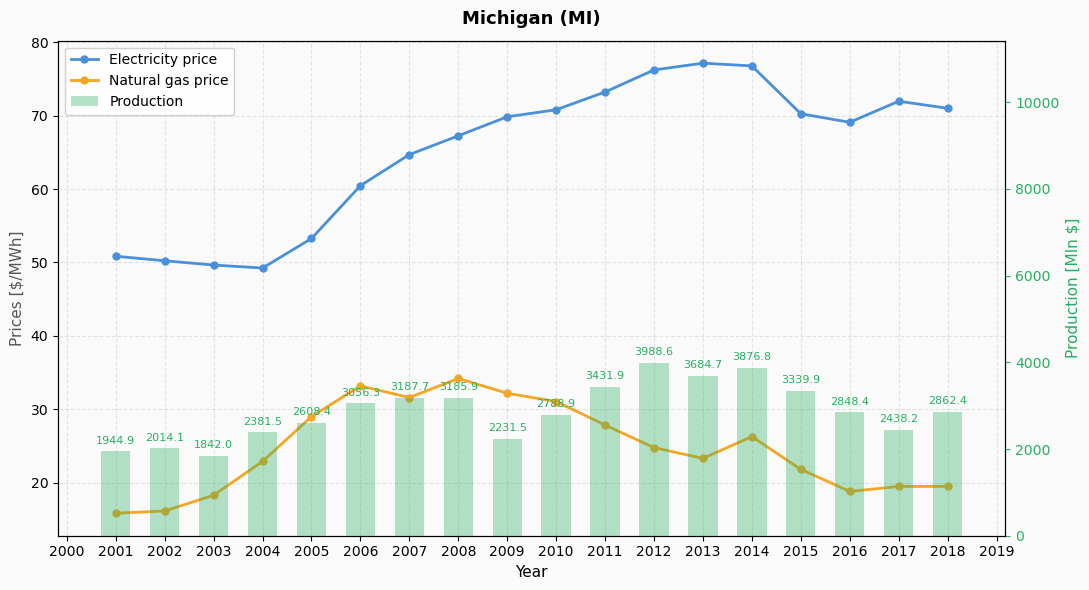

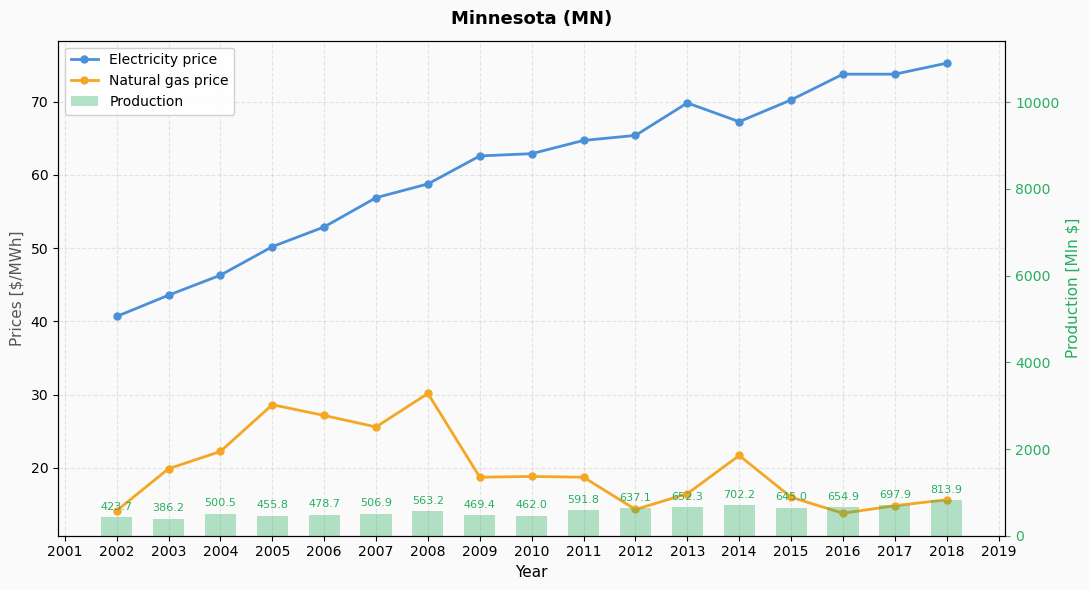

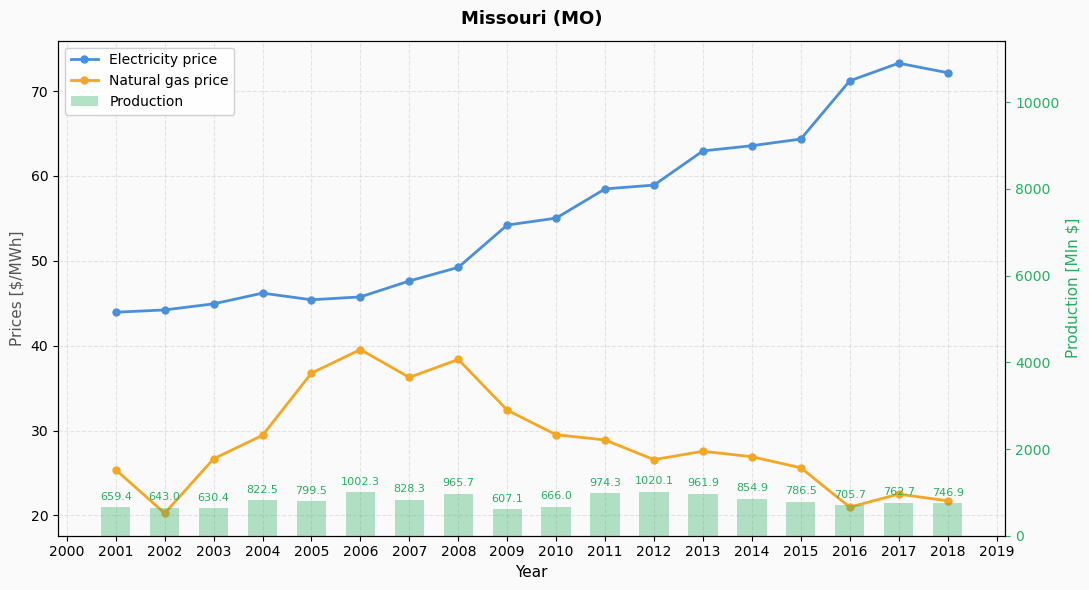

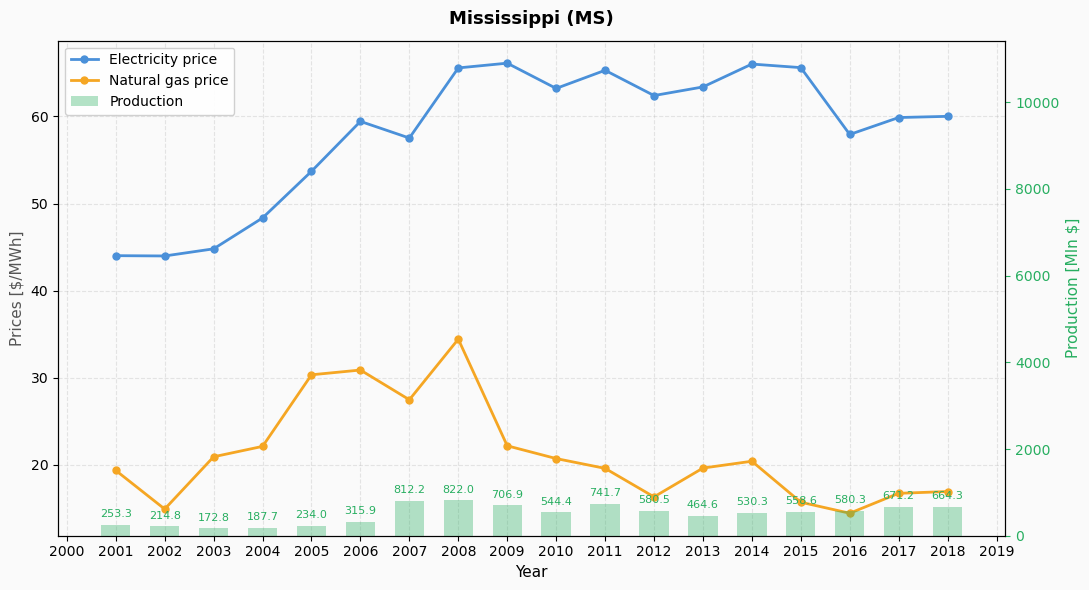

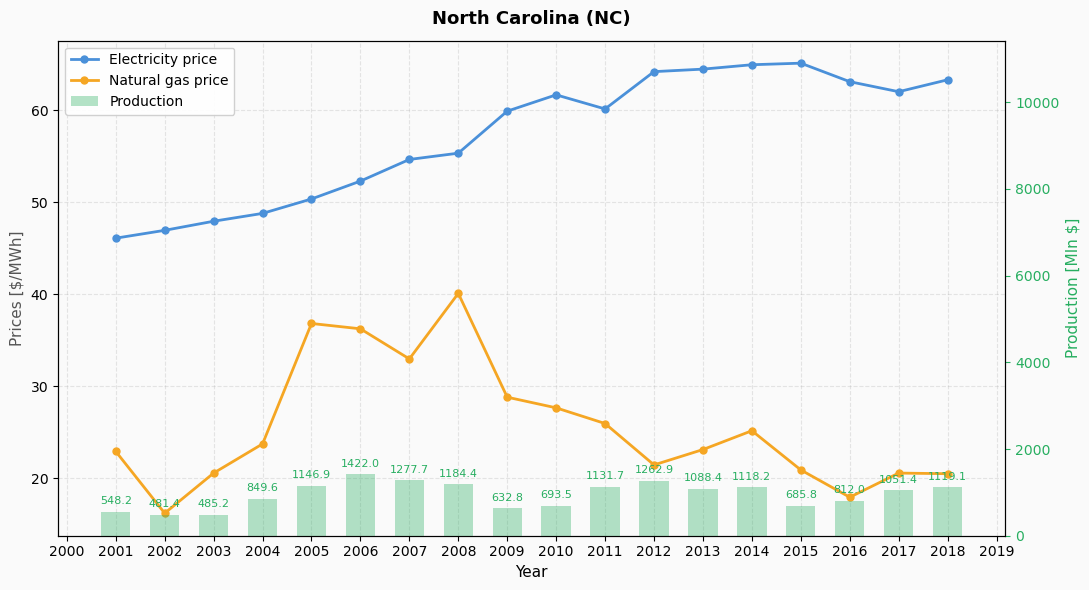

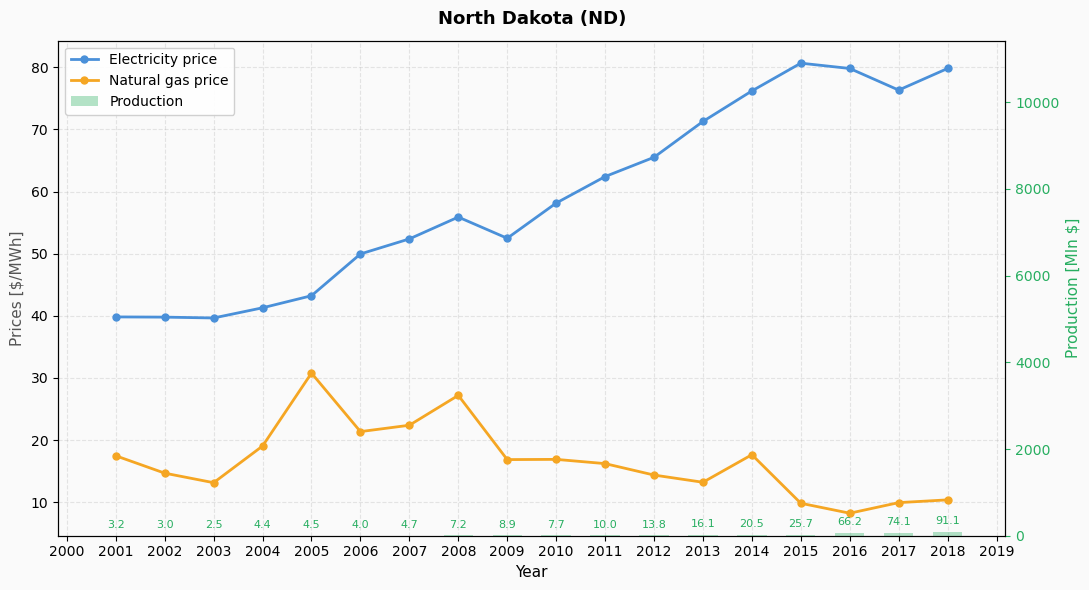

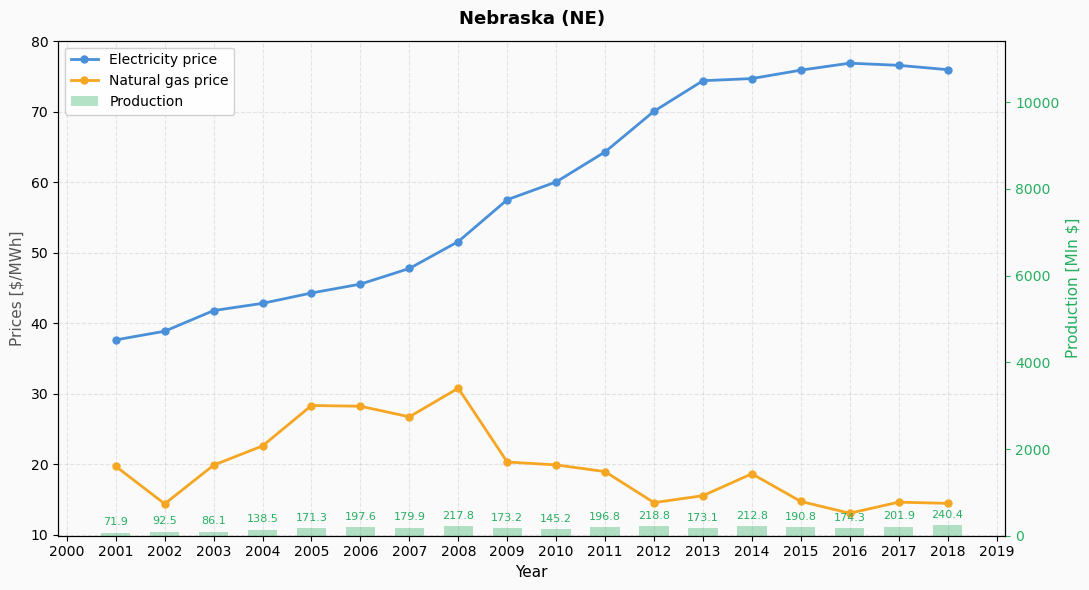

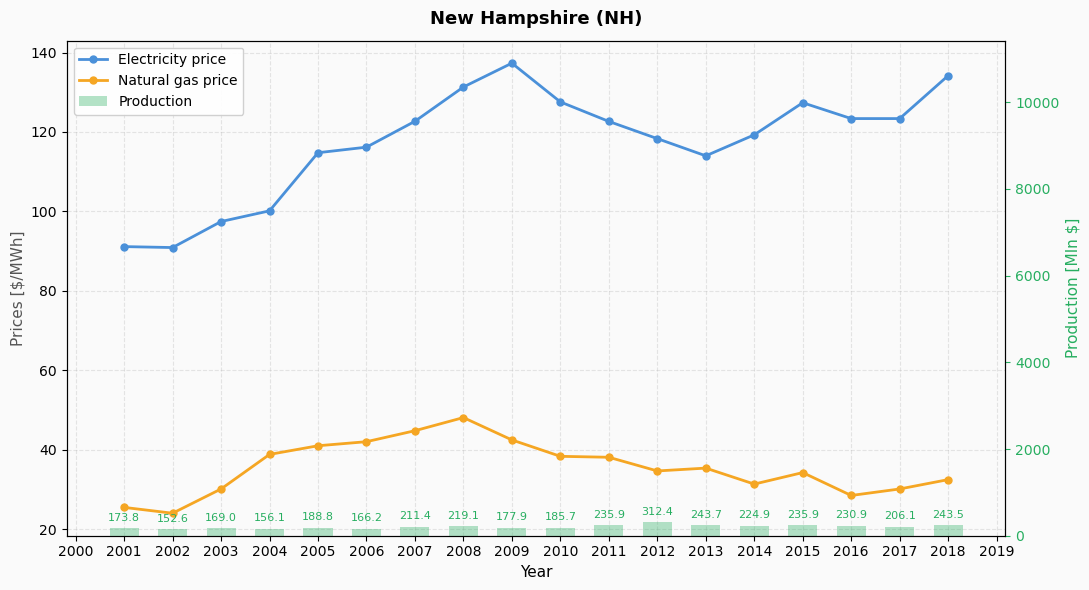

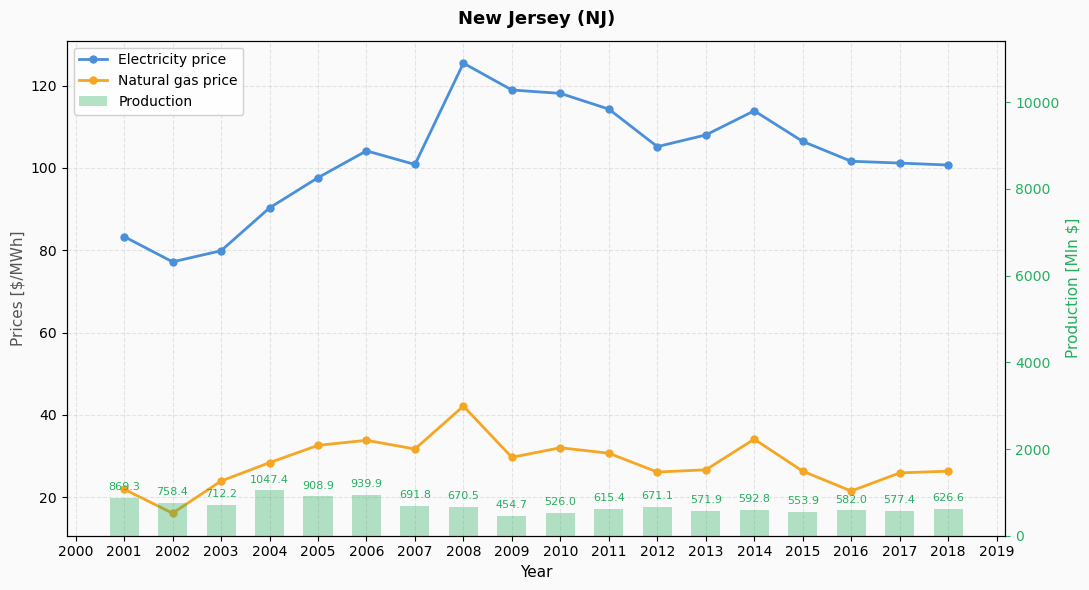

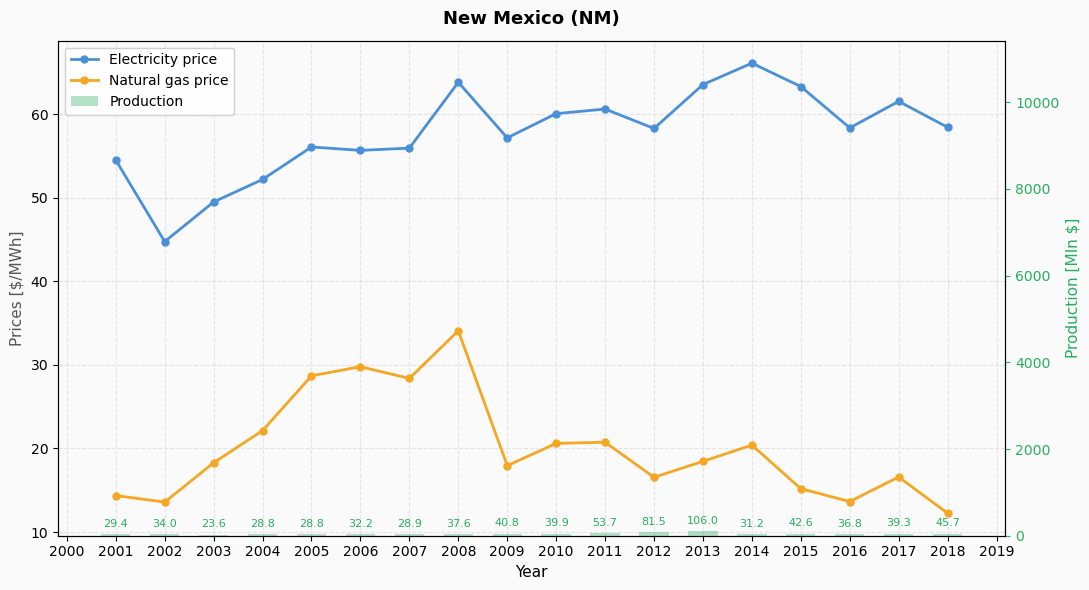

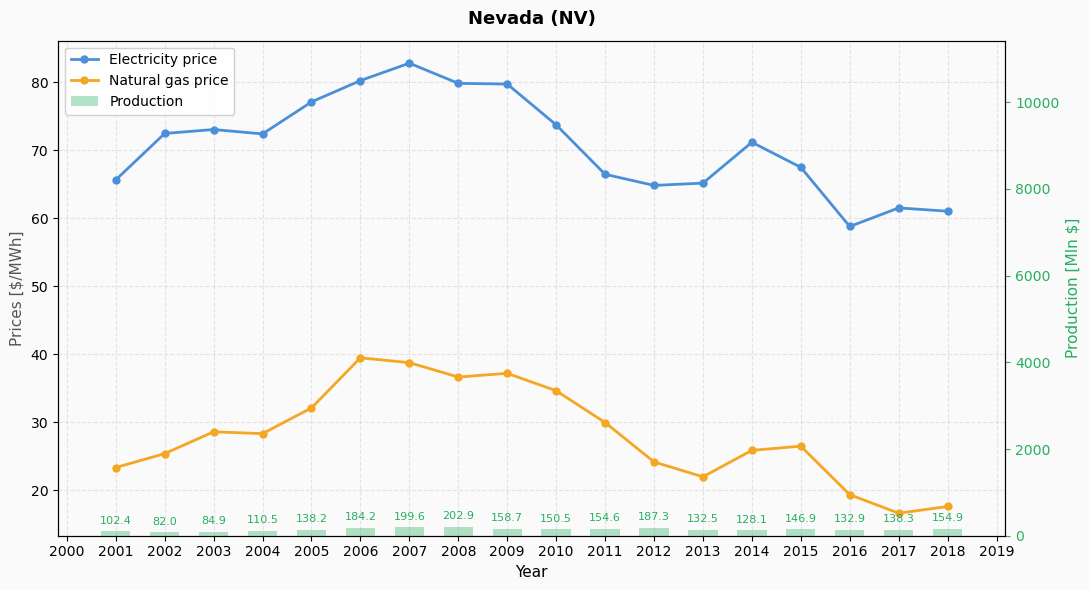

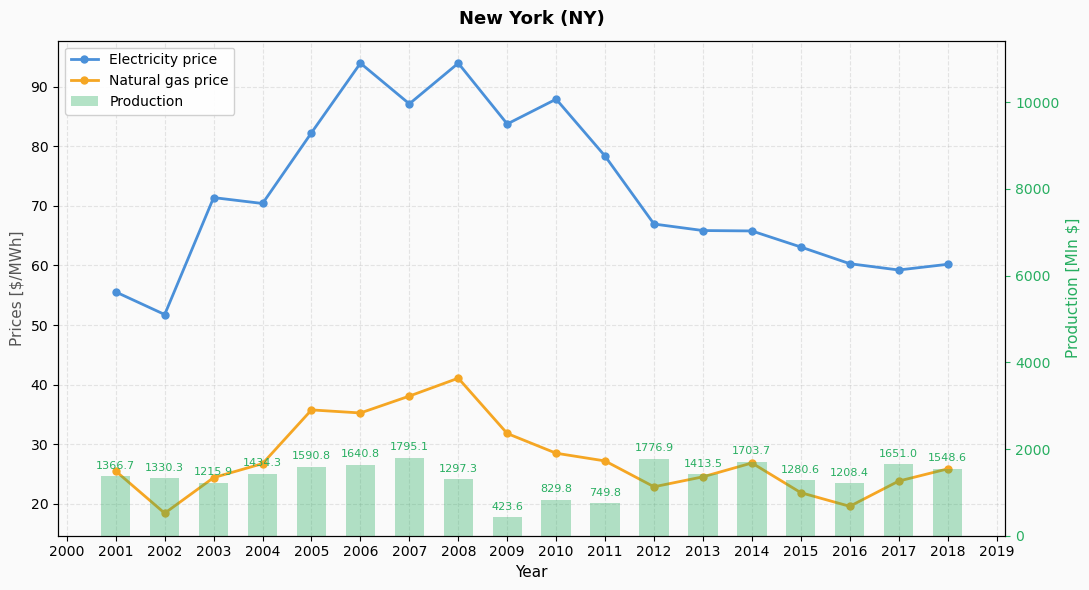

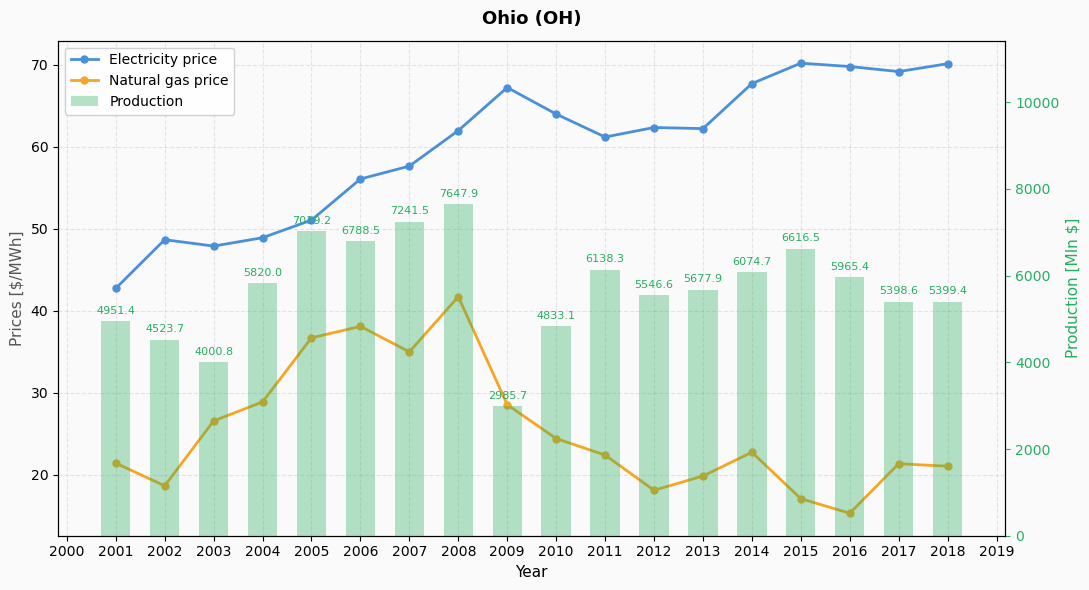

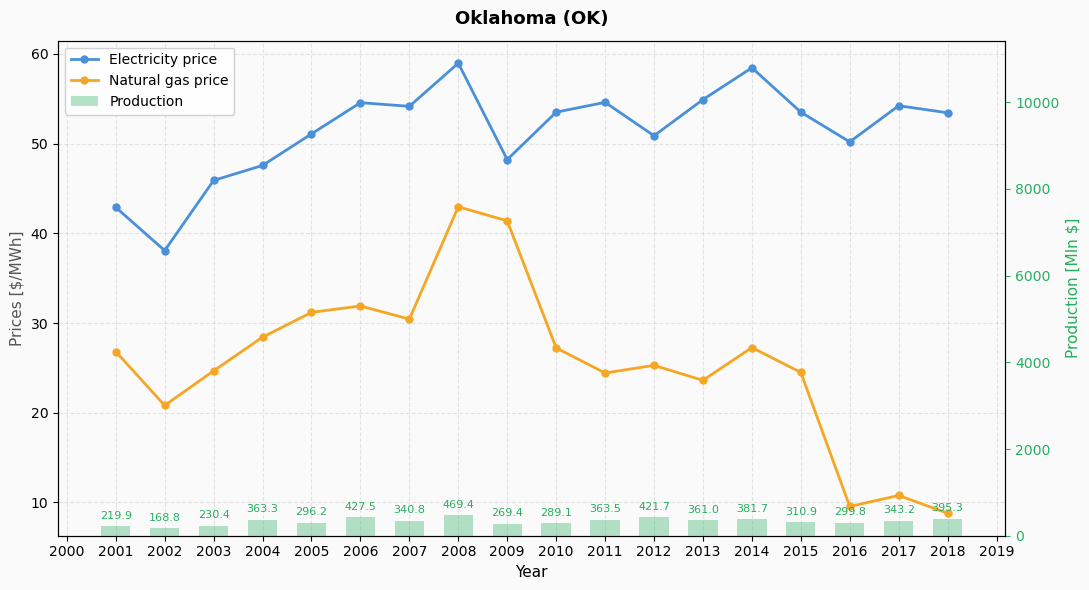

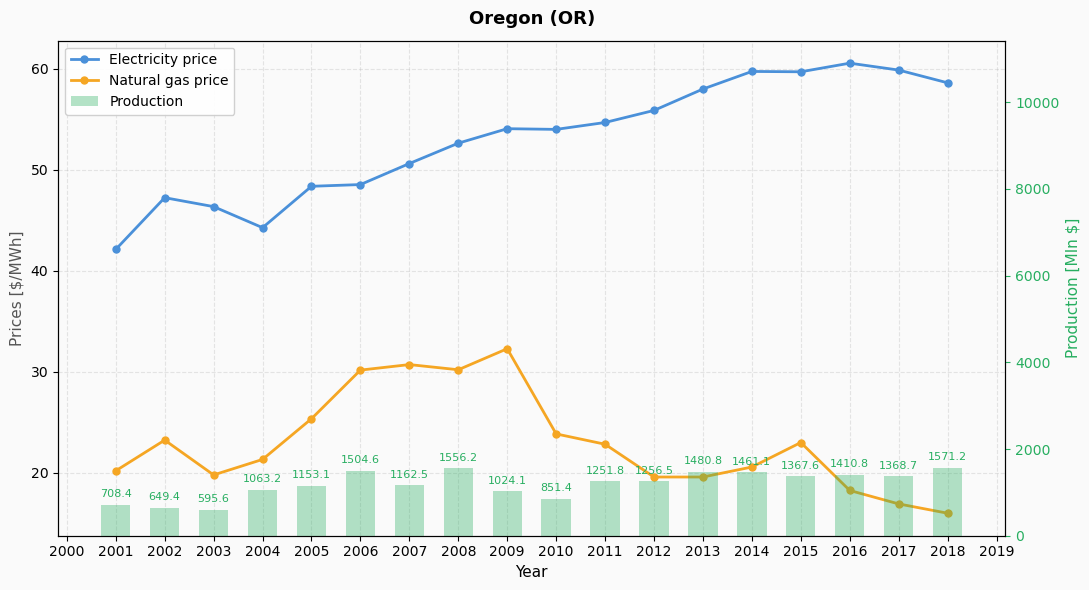

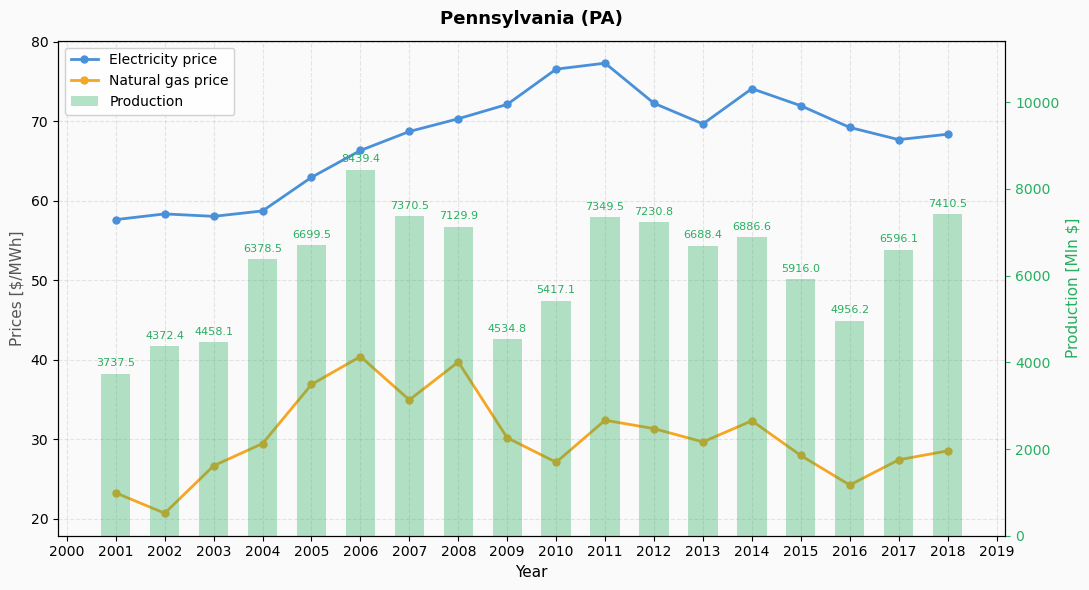

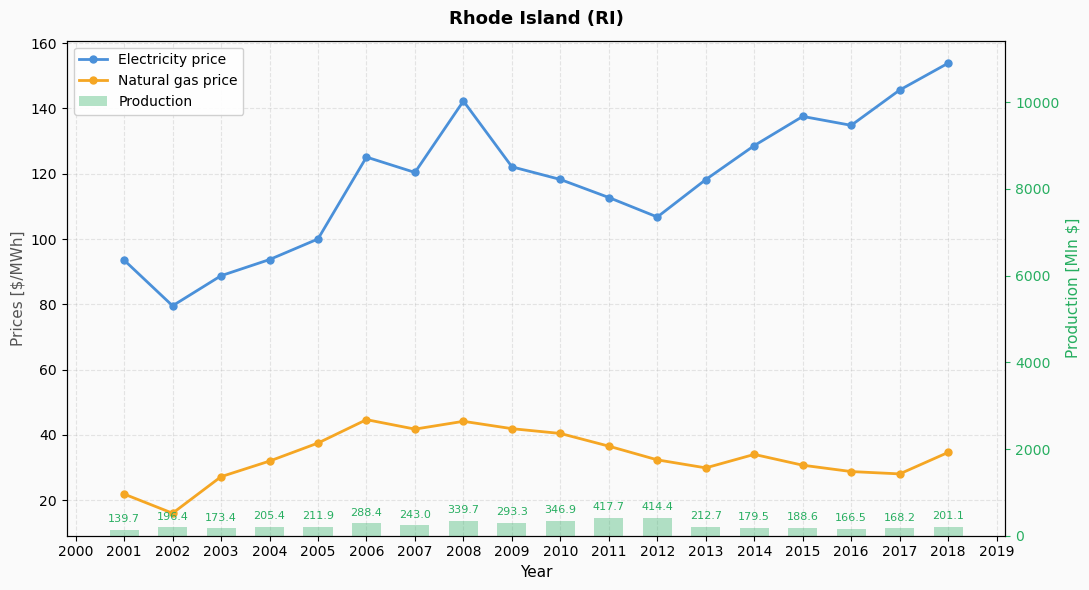

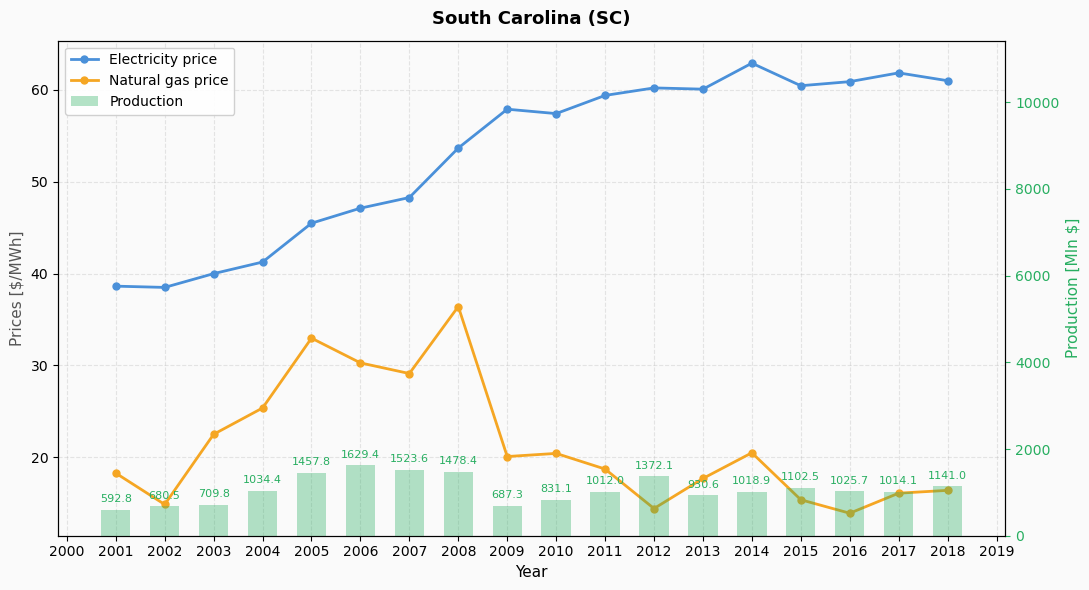

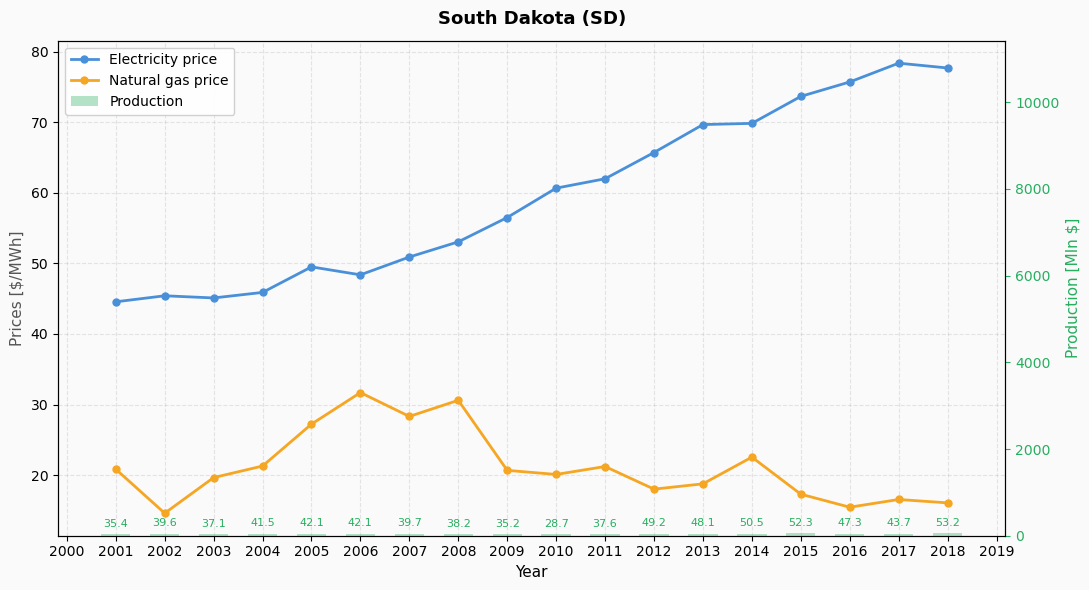

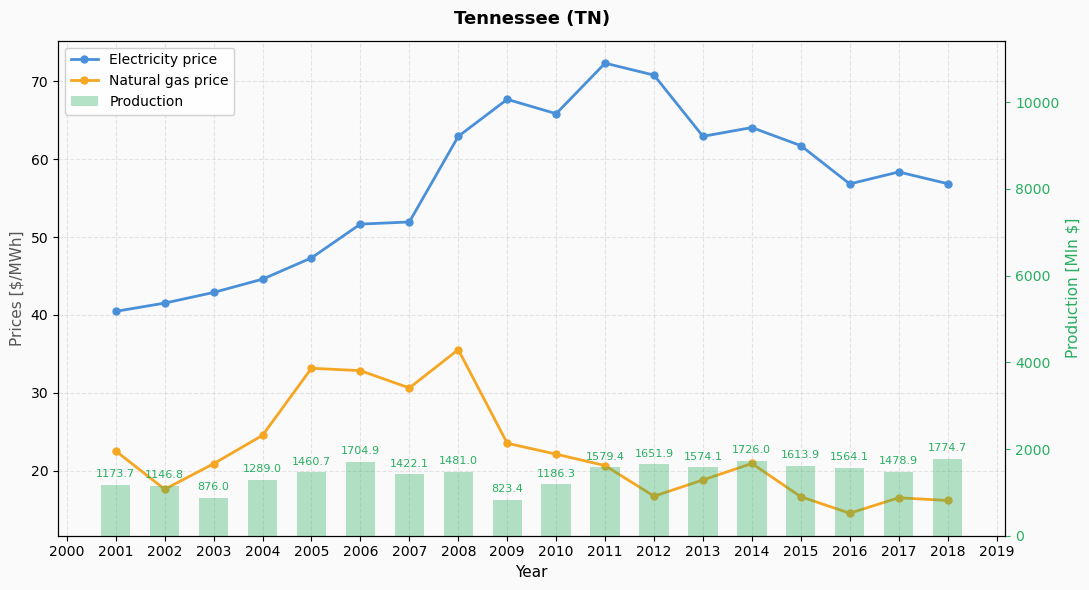

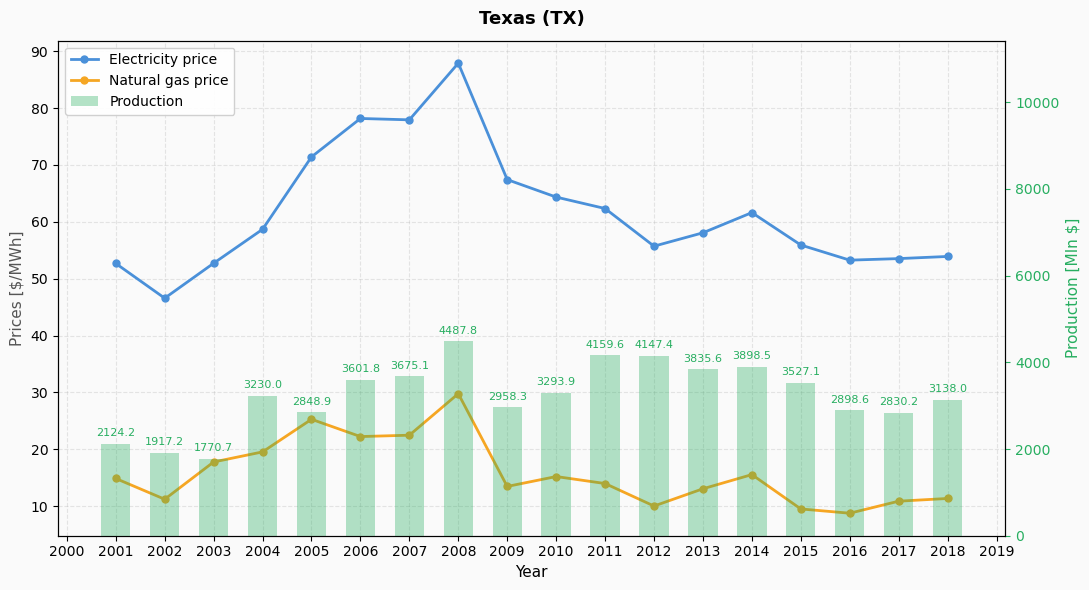

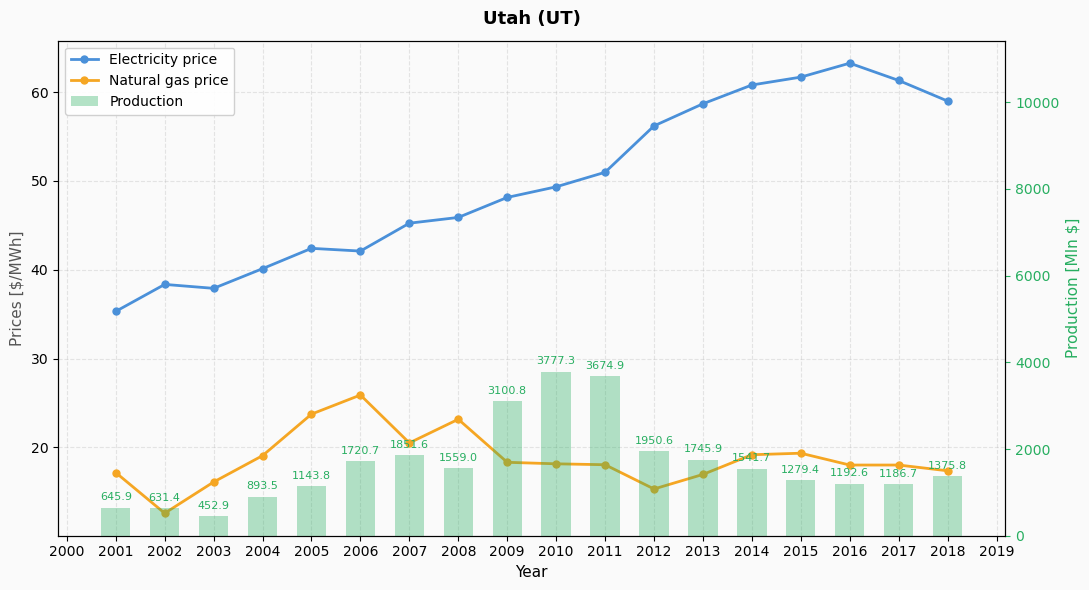

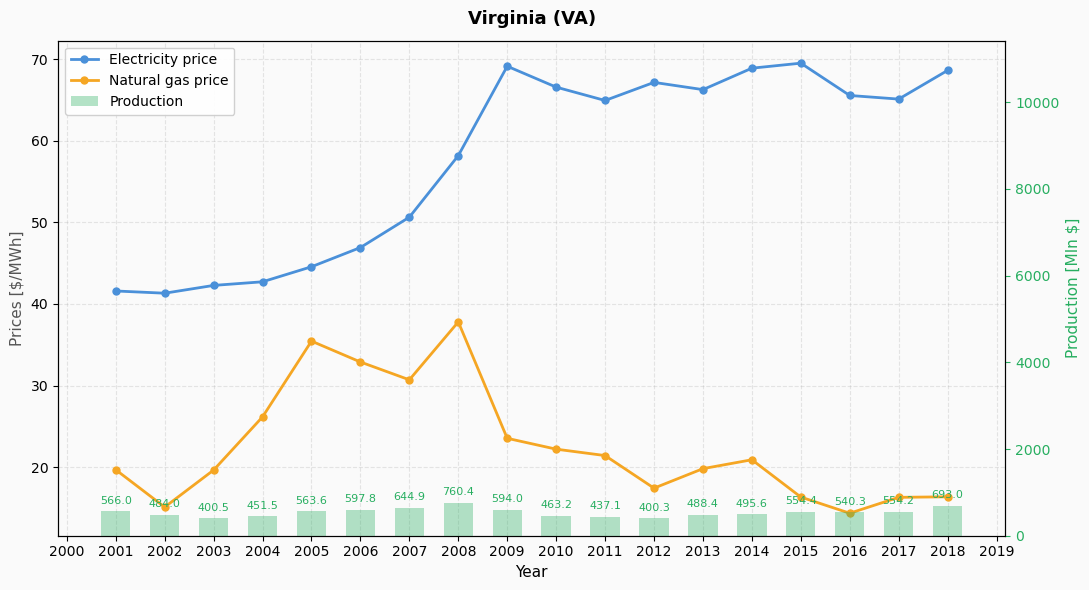

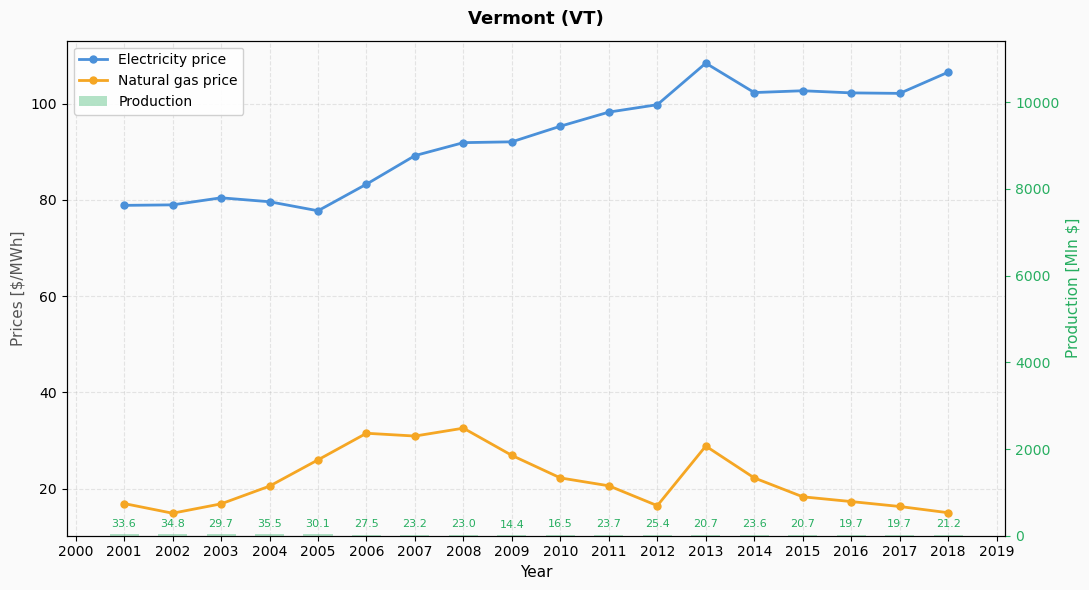

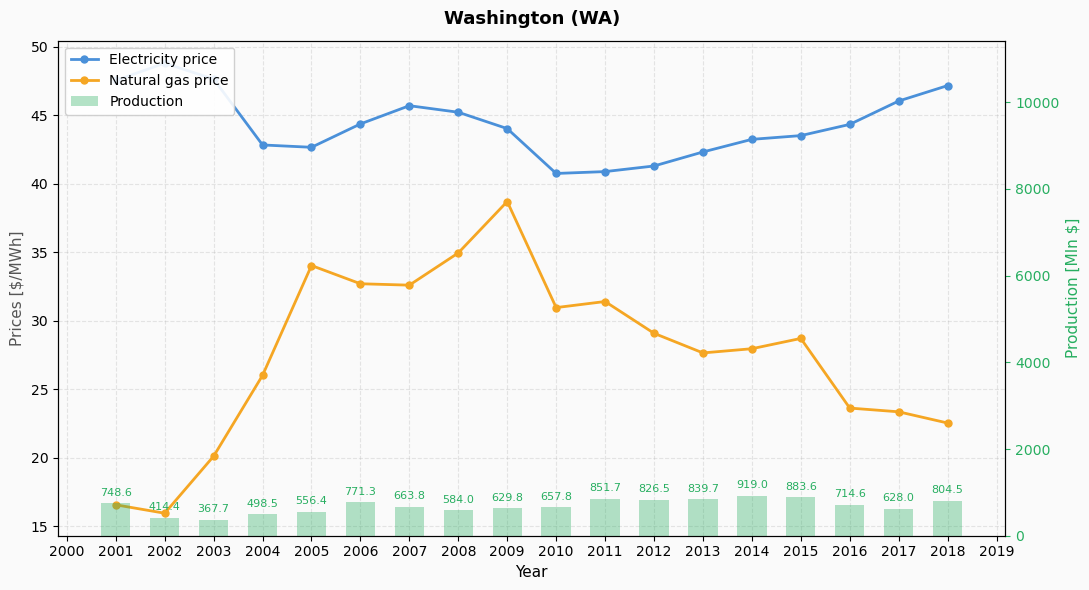

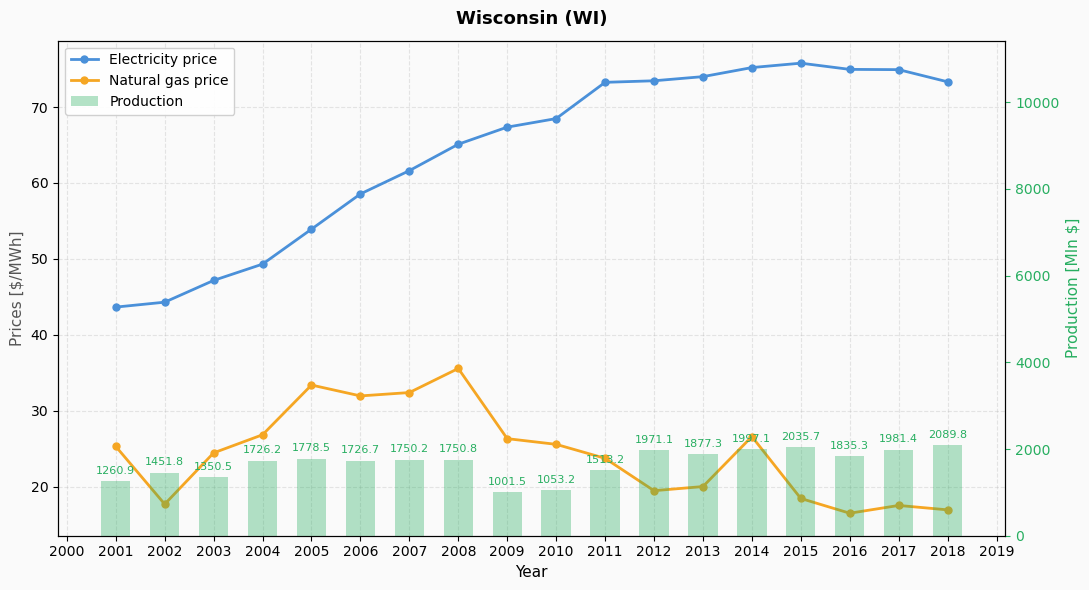

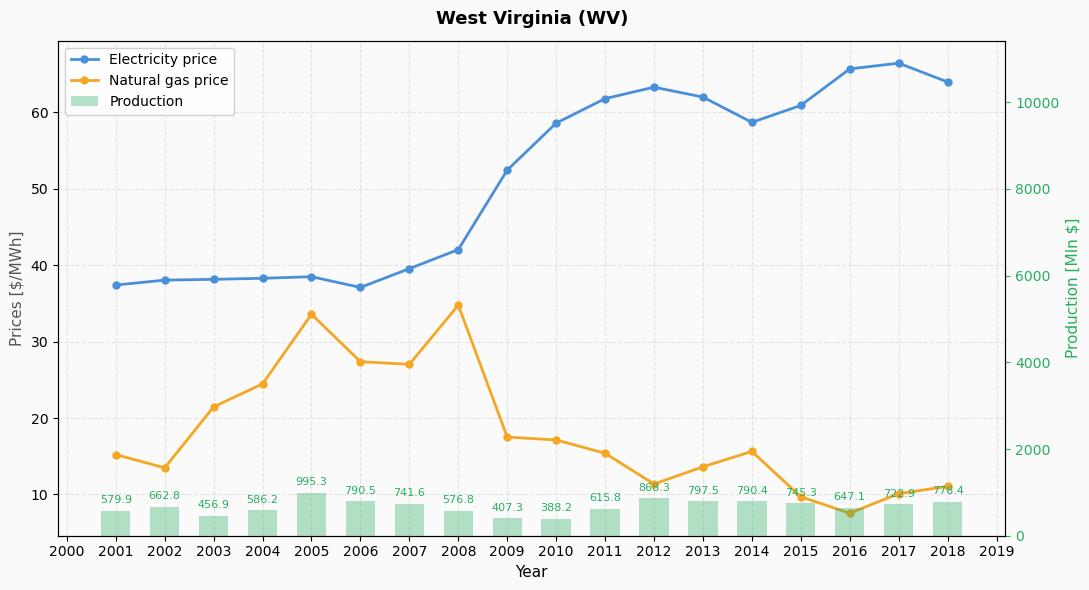

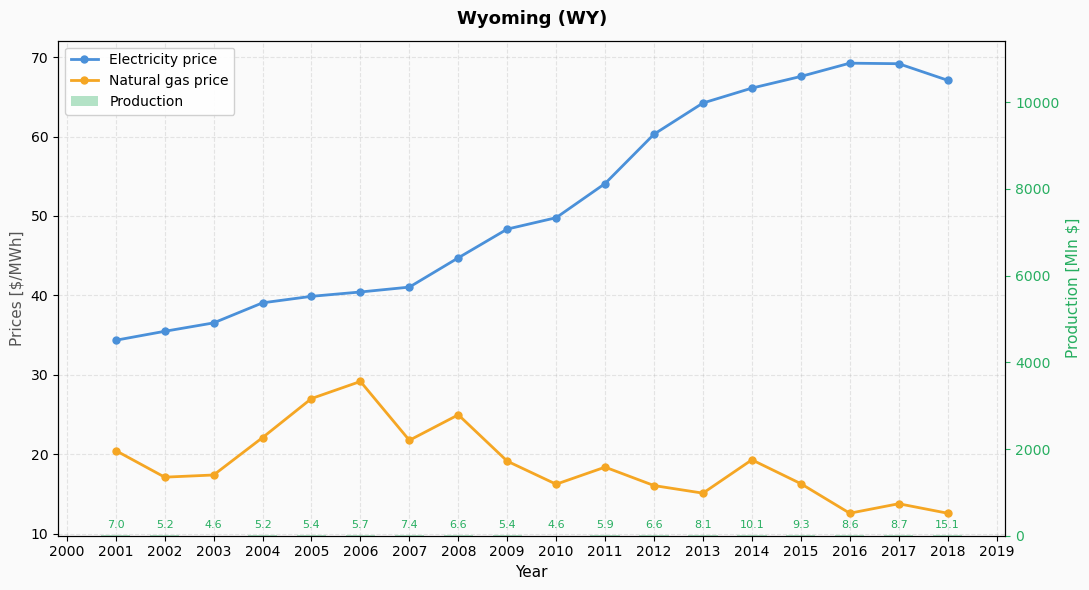

In [377]:
COLOR_ELECTRICITY = '#4A90D9'
COLOR_GAS         = '#F5A623'
COLOR_PRODUCTION  = '#27AE60'

state_names = df_states.set_index('stateId')['stateDescription'].to_dict()

y_max_production = pricesToProduction['aluminum_production[MlnDollars]'].max()

for state, group in pricesToProduction.groupby('stateId'):
    state_data = group[['period', 'Electricity price', 'Natural gas price', 'aluminum_production[MlnDollars]']].copy()
    state_data = state_data.sort_values('period').set_index('period')

    fig, ax1 = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('#FAFAFA')
    ax1.set_facecolor('#FAFAFA')

    ax1.plot(state_data.index, state_data['Electricity price'],
             color=COLOR_ELECTRICITY, marker='o', linewidth=2,
             markersize=5, label='Electricity price')
    ax1.plot(state_data.index, state_data['Natural gas price'],
             color=COLOR_GAS, marker='o', linewidth=2,
             markersize=5, label='Natural gas price')

    ax2 = ax1.twinx()
    ax2.bar(state_data.index, state_data['aluminum_production[MlnDollars]'],
            color=COLOR_PRODUCTION, alpha=0.35, width=0.6, label='Production')
    
    for x, y in zip(state_data.index, state_data['aluminum_production[MlnDollars]']):
        if y > 0:
            ax2.annotate(f'{y:.1f}',
                xy=(x, y),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center', va='bottom',
                color=COLOR_PRODUCTION, fontsize=8)

    ax2.set_ylim(0, y_max_production * 1.1)

    ax1.set_ylabel('Prices [$/MWh]', color='#555555', fontsize=11)
    ax2.set_ylabel('Production [Mln $]', color=COLOR_PRODUCTION, fontsize=11)
    ax2.tick_params(axis='y', colors=COLOR_PRODUCTION)
    ax1.set_xlabel('Year', fontsize=11)

    ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax1.grid(True, alpha=0.3, linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='upper left', framealpha=0.9, fontsize=10)

    state_label = state_names.get(state, state)
    plt.title(f'{state_label} ({state})', fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()

    output_dir = r"state_plots"
    os.makedirs(output_dir, exist_ok=True)

    fig_path = os.path.join(output_dir, f'{state}_production_price.png')
    fig.savefig(fig_path, dpi=150)
    plt.show()
    plt.close(fig)

Crisis in 2008 caused fall of production in all states, many of them never came back to the level from 2007
Bigger production of aluminium is in states with stabile, low prices of energy
Shale gas boom reduced gas price for 50-70$. It had long term impact on production
Reindustrialization is happening in states with lower energy prices. In states with higher energy prices industry is closing
States with small production are sensitive for single smelters and orders, where impact og enerrgy price can be omitted
In 2018 president Trump introduced a customs duty for aluminium, what stopped import and expanded production in USA


#### Alaska
Prices of electrical energy are very high according to other states. Very low level of production. Those two factors can be connected

#### Alabama
Low prices of electrical energy supports production.

#### Arkansas
Very low gas prices can be a factor which helps to raise production after the crisis

#### Arizona
Many changes in production with stable energy prices. Decrease of gas prices in the date of raising production, but according to many changes, there are other factors than energy prcies that have impact on it

#### California
High energy prices may cause long term fall of production

#### Colorado
Low costs of energy doesn't help in production growth, there are more reasons for low level of production than energy price

#### Connecticut
Despite the fact that electrical energy is expensive, production is very stabile on high level. It can be connected with specialized products which are performed there

#### District of Columbia
Production on very low level, energy prices very unstabile

#### Delaware
Low level of pruduction, high prices of gas may cause problems in start a production

#### Florida
Very low production until 2015 - than radical jump. It has to be verified with more data if it's not mistake

#### Georgia
Very low prices of gas supports production

#### Hawaii
Extremely high electic energy and gas prices causes that production in that state isn't rentable

####  Iowa
Slow raise of energy and fall of gas prices are connected with growth of production

#### Illinois
Smaller production connected with higher energy prices. Despite the fact that gas prices are very low, production didn't raised after economical crisis 2018 - probably many smelters were closed

#### Indiana
Low energy prices connected with high production

#### Kansas
Many changes un production can be connected with small market and changes due to producers and orders

#### Kentucky
Low energy prices are connected with growth of production. The fall of production in last years can be connected with older technology witch stops beeing effective

#### Louisiana
Electrical energy price with many changes, but cheap. Production on high level, can be connected with bery low prices of natural gas. 

#### Massachusetts
Very high prices of gas and electrical energy makes this state anatractive for aluminium production

#### Maryland
After 2012 drastical fall of production. Despite the fact of falling price of energy, production didn't came back to the level from 2011

#### Maine
Very low level of production with high prices of energy. It is not attractive state for smelters.

#### Michigan
Very big producer, raised after ther crisis in 2008 but according to raising level of energy many producers didn't survived on market

#### Minnesota
Production connected rather with fall of prices of gas than raises of electrical energy

#### Missouri
Many changes in production, rainsin electrical energy prices, falling gas prices does't support production. It can be a sign that manufacturers are leaving this state

#### Mississippi
Until 2006 very low production. Probslby in 2006 there were opened new factories, which held the level of production despite the crisis

#### North Carolina
Very unstable production level, can be connected with other factors than prices which are stabile

#### North Dakota
Low level of production can be connected with high level of energy prices. Rise of production after 2009 can be connected with shale gas boom

#### Nebraska
Low level of production with high energy prices. Rise of production connected with raise of energy prices probalby because fo usage of new, more efficient technology

#### New Hampshire
High energy prices stops manufacture

#### New Jersey
Raising energy prices connected with closing manufacture. Probably companies had mooved to others states

#### New Mexico
Low level of production caused by high prices of energy

#### Nevada
Production level addicted to trends on market than energy prices

#### New York
Very unstabile production level, supported by low prices of gas, but stopped by high level of energy

#### Ohio
One of the biggest producers, very low gas prices. After 2015 production started to get smaller despite the fact of cheaper energy, it can be connected with obsoltete technology

#### Oklahoma
Low level of energy and gas prices don't support production, probalby it is small market, very sensitive for other factors

#### Oregon
Production raises faster then energy prices. Very low level of gas supports production

#### Pennsylvania
Despite the fact of high prices of electrical energy, production raised up affter a crisis in 2008. It can be connected with low level of gas - shale gas boom in Pennsylvania made this state independent from electrical energy prices

#### Rhode Island
Very high prices of energy causes low level of production. Production stabile after 2013 can be connected with close a big producers in that year

#### South Carolina
Low level of electrical energy was connected with high level of production. After the crisi in 2008 production had never came back to the level from the time befor the crisis - probably many smelters were closed

#### South Dakota
Small market, few factories or contracts can dominate the market

#### Tennessee
Very big producer, thanks to cheap gas production in that state is rising

#### Texas
One of the biggest producer. Because of high energy prices, Production is falling downe year to year

#### Utah
Big raise after economical crisis, but companies didn't held that level of production with growing energy prices

#### Virginia
Raising production in 2017-2018 can be connected with expansion of high technology businesses

#### Vermont
High energy prices stops production

#### Washington
Very low energy prices doesn't support production, it cna be stopped by other factors

#### Wisconsin
Cheap gas after 2009. Production on higher level after crisis than before, probalby new investments in car or machinge industry

#### West Virginia
Many changes in production without connection with energy or gas prices. There are other factors which have influence on that

#### Wyoming
Expensive energy, cheap gas, little production. Higher production in the end of period can be a sign of development of minig industry

In [361]:
to_visualize = pd.merge(pricesToProduction, df_states, on='stateId', how='left')
to_visualize = to_visualize.reset_index(drop=True)
to_visualize.head()

,period,stateId,Electricity price,Natural gas price,aluminum_production[MlnDollars],energyLag1,stateDescription
0,2002,AK,76.49704,5.52744,0.9,NaN,Alaska
1,2003,AK,78.61248,5.15212,1.3,76.49704,Alaska
2,2004,AK,83.32104,6.58516,2.4,78.61248,Alaska
3,2005,AK,92.94288,8.80296,1.7,83.32104,Alaska
4,2006,AK,115.39384,13.03384,1.3,92.94288,Alaska


In [362]:
to_visualize.drop(columns=['stateId', 'Natural gas price'], inplace=True)   


In [363]:
to_visualize.to_csv('2018prices.csv', index=False)

## Power BI visualisation

!![Mapa stanów USA](2001.png)
!![Mapa stanów USA](2018.png)

According to 2001-2018 maps, the most of the production is located in the east shore

In further part I will analyze only states with top production and most popolated states. I will chceck if production is connected with population

In [425]:
df_top2018 = pricesToProduction[(pricesToProduction['period'] == 2018)].copy()
df_top2018.sort_values('aluminum_production[MlnDollars]', ascending=False, inplace=True)
df_top2018=df_top2018.head(10)
df_top2018.drop(columns=['energyLag1'], inplace=True)
df_top2018

,period,stateId,Electricity price,Natural gas price,aluminum_production[MlnDollars]
14,2018,IN,73.80156,19.89196,10382.4
36,2018,PA,68.37648,28.52432,7410.5
33,2018,OH,70.11660,21.01792,5399.4
1,2018,AL,60.11944,14.02332,4502.6
41,2018,TX,53.90960,11.36196,3138.0
21,2018,MI,71.00372,19.48252,2862.4
13,2018,IL,67.96704,18.39068,2562.2
4,2018,CA,132.01028,23.50868,2388.5
16,2018,KY,56.80980,14.29628,2362.8
2,2018,AR,56.40036,22.82628,2241.5


In [424]:
production_2018 = pricesToProduction[(pricesToProduction['period'] == 2018)].copy()
production_2018.reset_index(drop=True, inplace=True)
production_2018.drop(columns=['energyLag1'], inplace=True)


In [366]:
load_dotenv()

engine = create_engine(
    f"postgresql+pg8000://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [376]:
df_population = pd.read_sql("SELECT * FROM state_population", engine)
df_population.head()

,state_id,state,population
0,AL,Alabama,4887871
1,AK,Alaska,737438
2,AZ,Arizona,7171646
3,AR,Arkansas,3013825
4,CA,California,39557045


In [368]:
df_prod_population = production_2018.merge(
    df_population.rename(columns={'state_id': 'stateId'}),
    on='stateId',
    how='inner'
)

correlation = df_prod_population['aluminum_production[MlnDollars]'].corr(df_prod_population['population'])
print(f"Correlation production-population: {correlation:.3f}")

Correlation production-population: 0.352


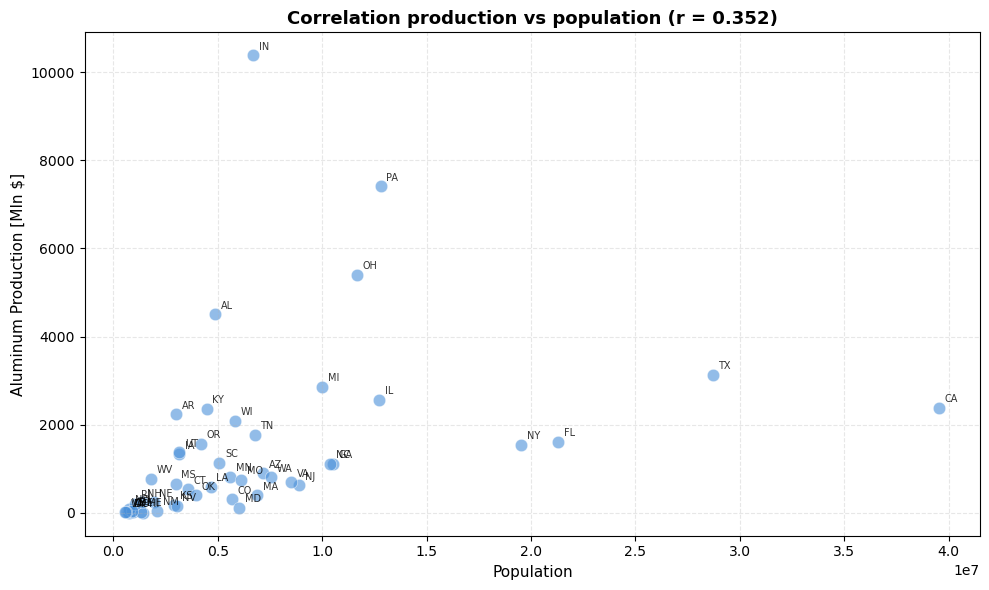

In [371]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_merged['population'], df_merged['aluminum_production[MlnDollars]'],
           alpha=0.6, color='#4A90D9', edgecolors='white', linewidth=0.5, s=80)

for _, row in df_merged.iterrows():
    ax.annotate(row['stateId'], 
                (row['population'], row['aluminum_production[MlnDollars]']),
                fontsize=7, alpha=0.8, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Population', fontsize=11)
ax.set_ylabel('Aluminum Production [Mln $]', fontsize=11)
ax.set_title(f'Correlation production vs population (r = {correlation:.3f})', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

There are some outliers, but the smallest production is in the least populated states

In [369]:
df_top_pop = df_population.sort_values('population', ascending=False).head(10)


In [370]:
top_prod_pop = df_top_pop.merge(df_top2018, left_on='state_id', right_on='stateId', how='inner')
print('There is '+str(len(top_prod_pop))+' from 10 states with the biggest production in 10 most populated states.')

There is 6 from 10 states with the biggest production in 10 most populated states.


 Despite the fact correlation was low, there is connection between population and production.

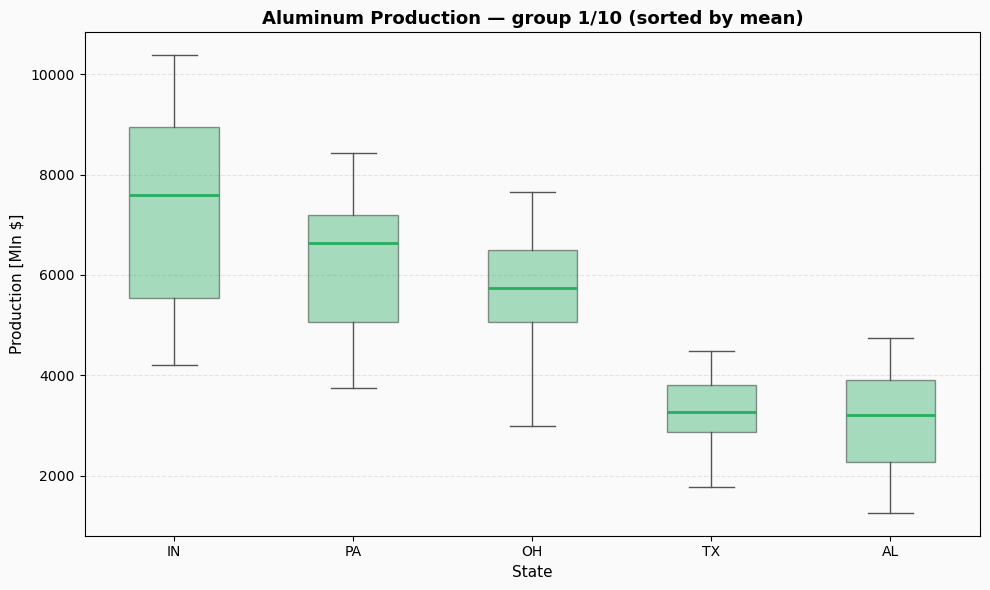

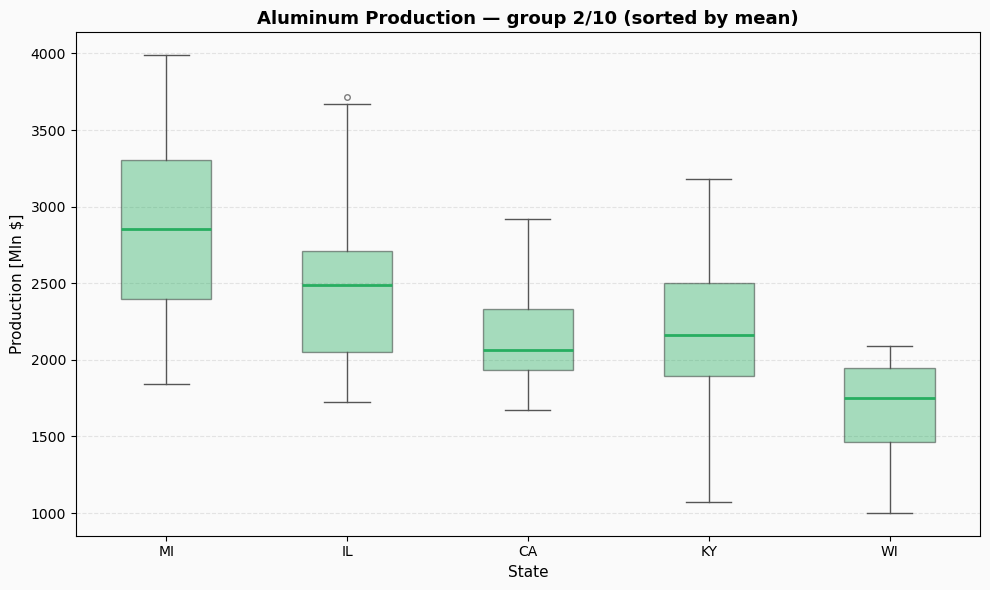

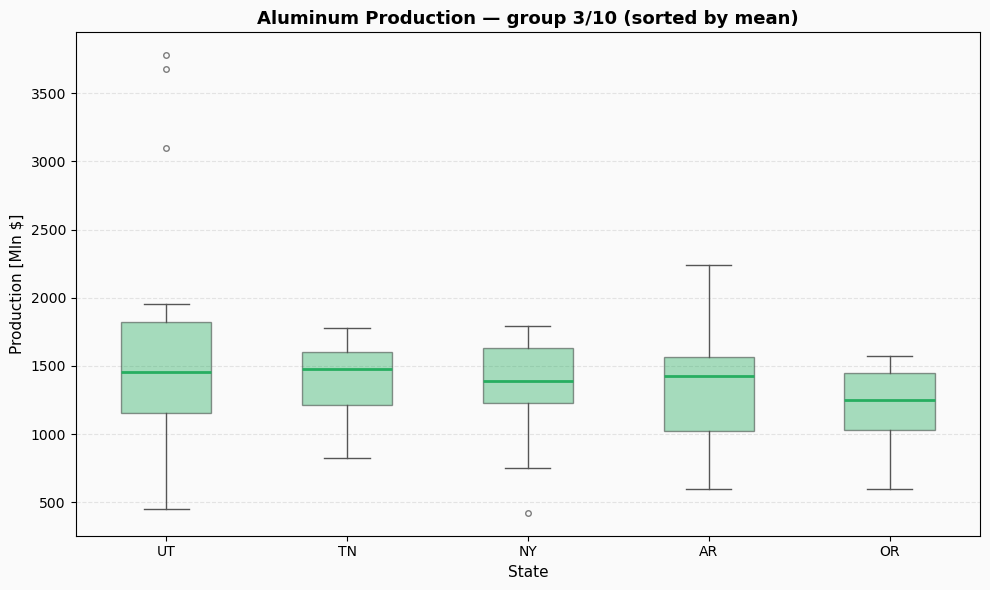

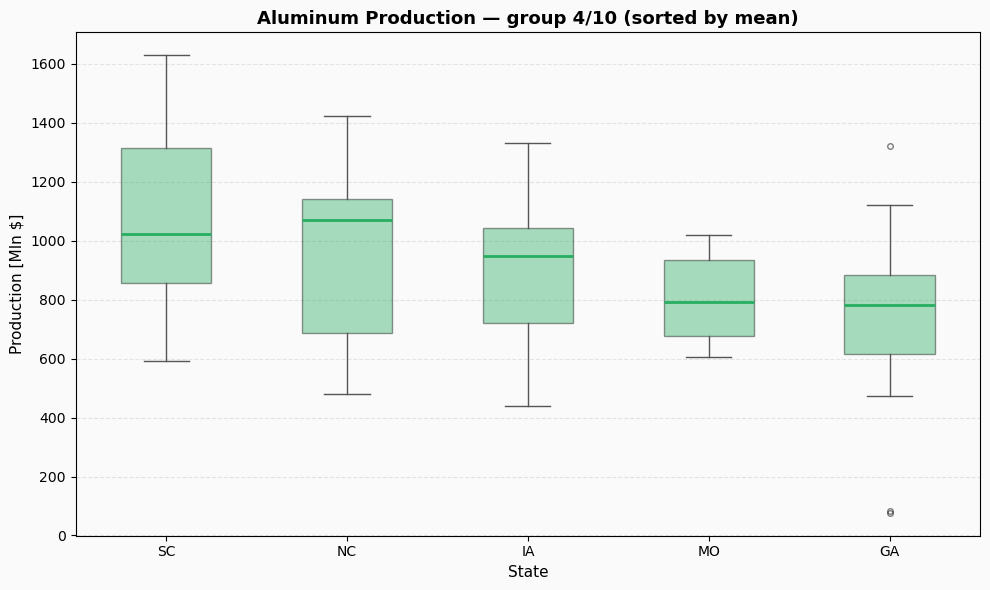

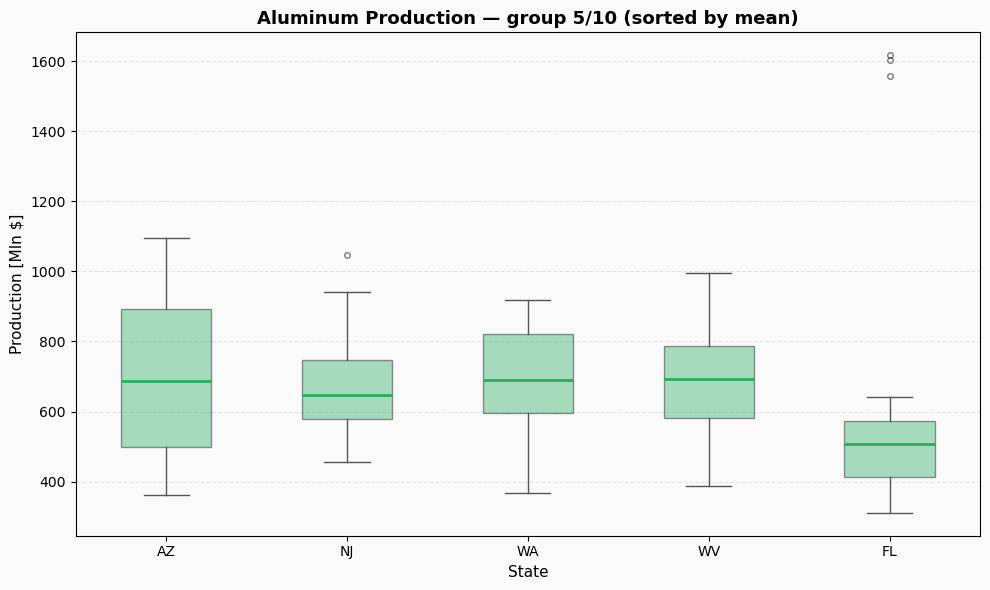

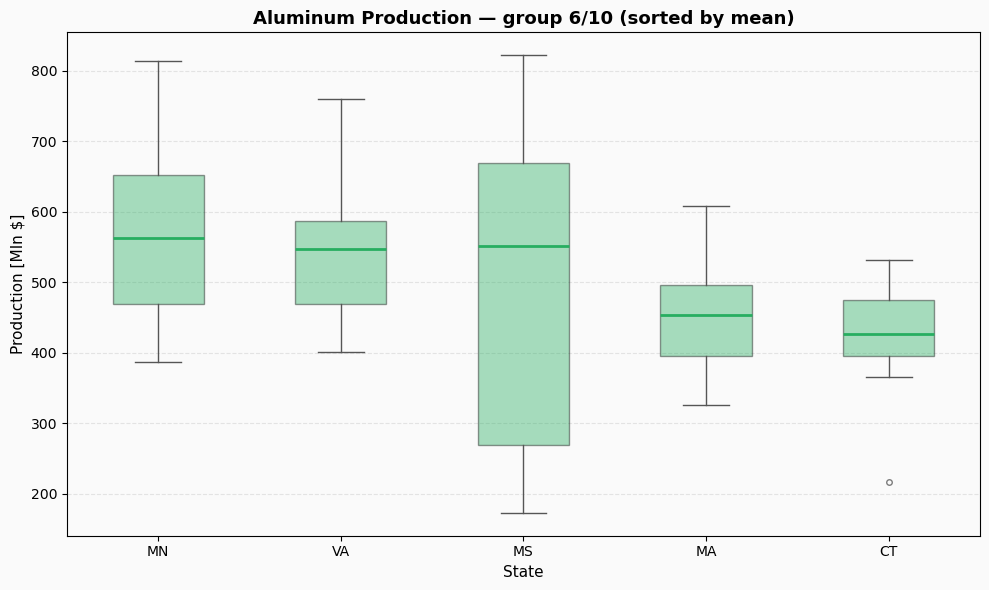

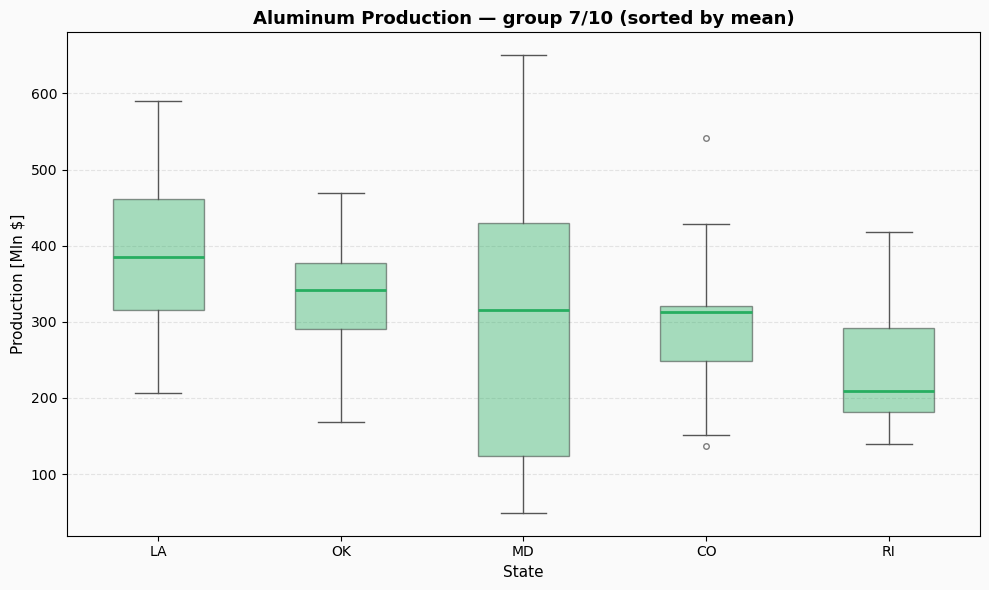

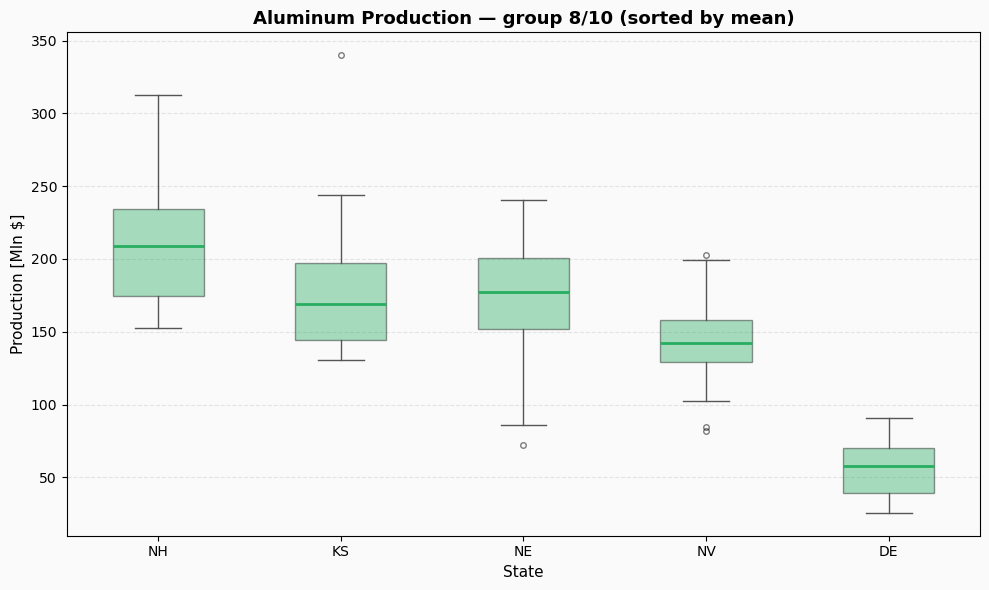

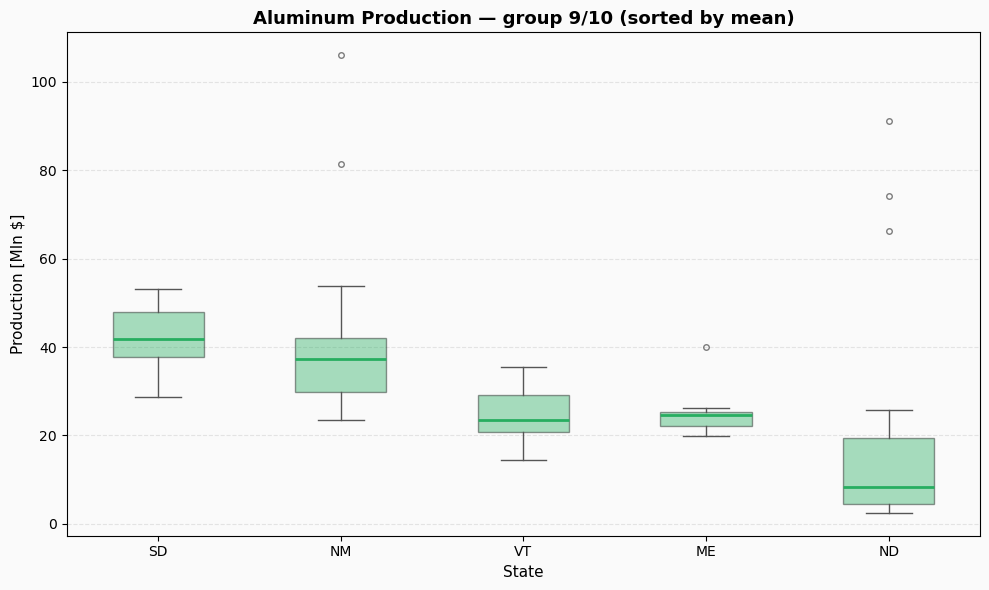

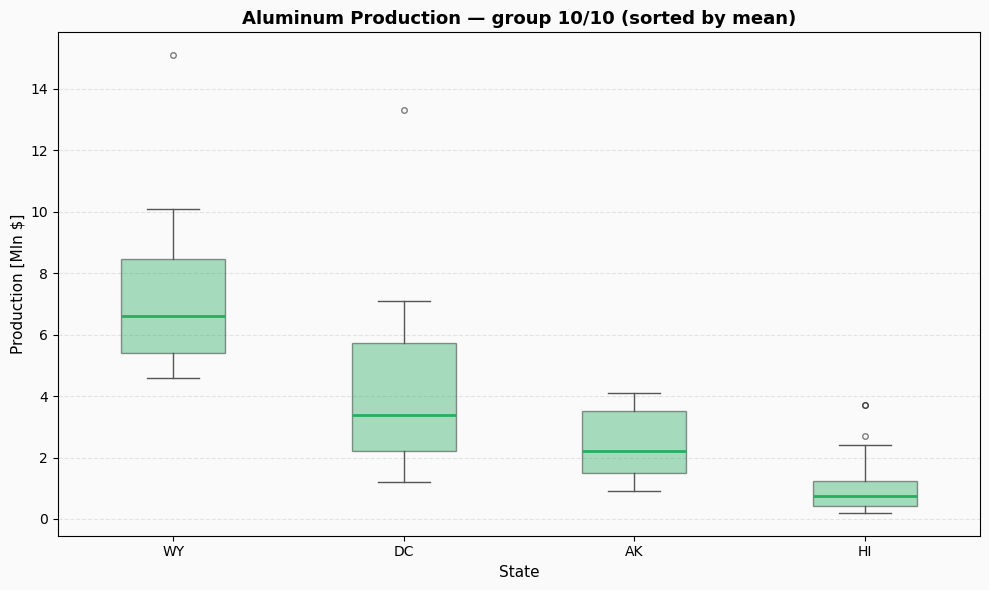

In [426]:
top_states = (pricesToProduction.groupby('stateId')['aluminum_production[MlnDollars]']
              .mean()
              .sort_values(ascending=False)
              .index)

chunks = [top_states[i:i+5] for i in range(0, len(top_states), 5)]

for i, chunk in enumerate(chunks):
    df_chunk = pricesToProduction[pricesToProduction['stateId'].isin(chunk)]

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    data_by_state = [
        df_chunk[df_chunk['stateId'] == state]['aluminum_production[MlnDollars]'].dropna().values
        for state in chunk
    ]

    bp = ax.boxplot(data_by_state, tick_labels=chunk, patch_artist=True,
                    boxprops=dict(facecolor=COLOR_PRODUCTION, alpha=0.4),
                    medianprops=dict(color=COLOR_PRODUCTION, linewidth=2),
                    whiskerprops=dict(color='#555555'),
                    capprops=dict(color='#555555'),
                    flierprops=dict(marker='o', color=COLOR_PRODUCTION, alpha=0.5, markersize=4))

    ax.set_xlabel('State', fontsize=11)
    ax.set_ylabel('Production [Mln $]', fontsize=11)
    ax.set_title(f'Aluminum Production — group {i+1}/{len(chunks)} (sorted by mean)',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')

    plt.tight_layout()
    plt.show()

Outliers which are shown here are a proove of conclusions from previous plots:
    - down outliers are values from crisis 2008, those values are in almost every state
    - up outliers are mainly in states with small production, where they can be single orders from single smelters

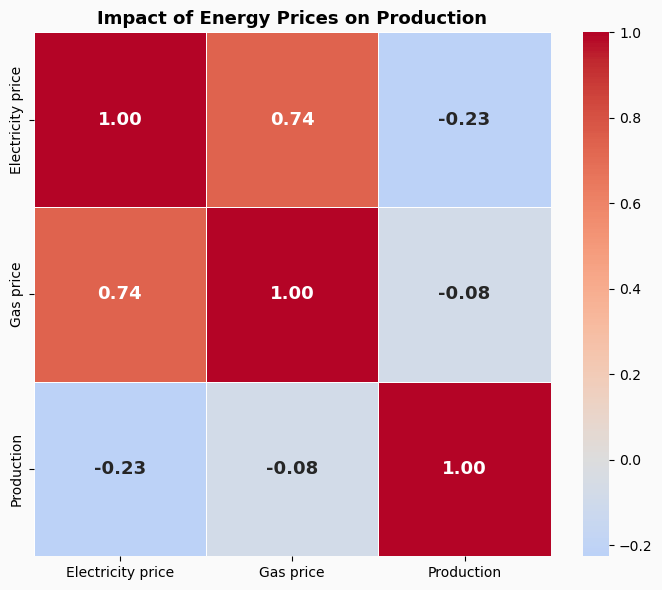

In [423]:
import seaborn as sns

df_agg = (pricesToProduction
          .groupby('stateId')[['Electricity price', 'Natural gas price', 'aluminum_production[MlnDollars]']]
          .mean()
          .dropna())

df_agg.columns = ['Electricity price', 'Gas price', 'Production']

corr_matrix = df_agg.corr()

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})

ax.set_title('Impact of Energy Prices on Production', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

There is strong relation between gas and electricity price. Very often their trends looked familiar. Their trends were almost scalable in many states.

### Data and Scope of the Analysis
The analysis covers the years 2001–2018 for all US states. Data was obtained from the U.S. Energy Information Administration (EIA API) and includes electricity prices, natural gas prices, and the value of aluminum production in the industrial sector.

### Key Findings

**1. Energy and Gas Price Relationship**
Electricity and natural gas prices exhibit a strong intercorrelation—their trends were nearly scalable across most states. Price increases for one energy source were typically associated with increases in the other, suggesting common macroeconomic factors driving both variables.

**2. Weak correlation between production and population (r = 0.352)**
Aluminum production volume is not strongly correlated with state population. The largest producer was Indiana (IN)—a state with a relatively small population (~6.5M)—which demonstrates that the aluminum industry is concentrated in locations favorable for energy and raw materials, rather than in densely populated areas.

**3. The Impact of Energy Prices on Production—State Variation**
The correlation between electricity prices and aluminum production varies significantly across states. Some states exhibit a strong negative correlation (higher energy prices = lower production), consistent with the economic logic of energy-intensive production. Other states exhibit no such correlation, which may suggest long-term energy contracts or other local factors.

**4. Production Outliers**
The IQR analysis revealed the presence of outliers in several states—sharp production declines in some years may indicate smelter closures, economic crises (visible effect in 2008–2009), or changes in industrial structure.

**5. Units – Standardization**
Data originally expressed in BTU units has been converted to MWh, which increases readability for European consumers and facilitates international comparisons